# Assignment 4 (CSI 4142)

# Group Information

- **Student name**: Shabrina Sharmin
- **Student Id**: 300230297
- **Group no**: A-85

# Unsupervised Learning Clustering and Recommendations

## Description of the dataset
Data columns (total 27 columns):

 0   adult                      45466 non-null  object        
 1   belongs_to_collection      4494 non-null   object        
 2   budget                     45466 non-null  float64       
 3   genres                     45466 non-null  object        
 4   homepage                   7782 non-null   object        
 5   id                         45466 non-null  object        
 6   imdb_id                    45449 non-null  object        
 7   original_language          45455 non-null  object        
 8   original_title             45466 non-null  object        
 9   overview                   44512 non-null  object        
 10  popularity                 45466 non-null  float64       
 11  poster_path                45080 non-null  object        
 12  production_companies       45463 non-null  object        
 13  production_countries       45463 non-null  object        
 14  release_date               45376 non-null  datetime64[ns]
 15  revenue                    45466 non-null  float64       
 16  runtime                    45466 non-null  float64       
 17  spoken_languages           45460 non-null  object        
 18  status                     45379 non-null  object        
 19  tagline                    20412 non-null  object        
 20  title                      45460 non-null  object        
 21  video                      45460 non-null  object        
 22  vote_average               45466 non-null  float64       
 23  vote_count                 45466 non-null  float64       
 24  production_companies_name  45463 non-null  object        
 25  production_countries_name  45463 non-null  object        
 26  spoken_languages_name      45466 non-null  object      

## **Access data**

### **Setting up the appropriate libraries needed for the assignment** ##
Run the follwing code below to set up the appropriate libraries that are needed

In [1]:
## Install Kaggle library
!pip install -q kaggle
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy
!pip install nltk
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.2 MB/s eta 0:00:00


### **Download the dataset**

In [2]:
## Download the dataset 1
import kagglehub
# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
print("Path to dataset files:", path)


100%|██████████| 228M/228M [00:08<00:00, 27.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rounakbanik/the-movies-dataset/versions/7


## Imports

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ast
import datetime
from datetime import datetime
from datetime import date
# import re as re
# from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
import Levenshtein
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from scipy.spatial import distance
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Read the files

In [4]:
### read the first dataset
movies_metadata_df = pd.read_csv(path+ '/movies_metadata.csv')
movies_metadata_df.head()
movies_metadata_df.info()
movies_metadata_df.describe()

### read the ratings dataset
ratings_df = pd.read_csv(path + '/ratings_small.csv')
ratings_df.head()
ratings_df.info()
ratings_df.describe()




<ipython-input-4-4e4a39a072b2>:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata_df = pd.read_csv(path+ '/movies_metadata.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


## **Data Cleaning**

### a. Data pre-pocessing
The dataset has many features that are  in json format. The json format is hard to use with dataframe. Also, within the json format, there are many keys such as 'id' is not necessary for this study. Therefore, attributes such as 'production_companies', and 'production_countries' were used to extract the countries or companies name which can be used more effectively.
Additionaly, other attributs such as 'budget', 'popularity', 'release_date' were converted into correct/usable data types like int64 of float64

In [5]:
## copy the dataset
movies_metadata_df_copy = movies_metadata_df.copy()

### func to extract company name from 'production_companies' col which contains json formatted data
def extract_production_company_name(production_companies):
  try:
    # check if the value for 'production_companies' is string
    if isinstance(production_companies, str) and not pd.isnull(production_companies):
      # convert the string to a list of dictinaries
      production_companies = ast.literal_eval(production_companies)
      # check if 'production_companies' is an iterable (list)
      if isinstance(production_companies, list):
        # extract the name key from each dict
        return [company['name'] for company in production_companies]
    else:
      # Return an empty list if the input is not as expected or parsing fails
      return []
  except (SyntaxError, ValueError):
    return []



### func to extract country name name from 'production_country' col which contains json formatted data
def extract_production_country_name(production_countries):
  try:
    # check if the value for 'production_companies' is string
    if isinstance(production_countries, str) and not pd.isnull(production_countries):
      # convert the string to a list of dictinaries
      production_countries = ast.literal_eval(production_countries)
      # check if 'production_companies' is an iterable (list)
      if isinstance(production_countries, list):
        # extract the name key from each dict
        return [country['name'] for country in production_countries]
    else:
      # Return an empty list if the input is not as expected or parsing fails
      return []
  except (SyntaxError, ValueError):
    return []


### func to extract country name name from 'production_country' col which contains json formatted data
def extract_language(spoken_languages):
  try:
    # check if the value for 'spoken_languages' is string
    if isinstance(spoken_languages, str) and not pd.isnull(spoken_languages):
      # convert the string to a list of dictinaries
      languages = ast.literal_eval(spoken_languages)
      # check if 'production_companies' is an iterable (list)
      if isinstance(languages, list):
        # extract the name key from each dict
        return [language['name'] for language in languages]
    else:
      # Return an empty list if the input is not as expected or parsing fails
      return []
  except (SyntaxError, ValueError):
    return []


# Convert the 'budget' column to float (numeric) type
movies_metadata_df_copy['budget'] = pd.to_numeric(movies_metadata_df_copy['budget'], errors='coerce')
# Convert the 'popularity' column to float
movies_metadata_df_copy['popularity'] = pd.to_numeric(movies_metadata_df_copy['popularity'], errors='coerce')
# convert release date into date time
movies_metadata_df_copy['release_date'] = pd.to_datetime(movies_metadata_df_copy['release_date'], errors='coerce')

# Process the 'genre' column
movies_metadata_df_copy['genres'] = movies_metadata_df_copy['genres'].apply(lambda x: [genre['name'] for genre in ast.literal_eval(x)])
#print(movies_metadata_df_copy['genres'])

# process 'production_company' column to retrieve the company name
movies_metadata_df_copy['production_companies_name'] = movies_metadata_df_copy['production_companies'].apply(extract_production_company_name)
#print(movies_metadata_df_copy['production_companies_name'])


# process 'production_countries' column to retrieve the country name
movies_metadata_df_copy['production_countries_name'] = movies_metadata_df_copy['production_countries'].apply(extract_production_country_name)
#print(movies_metadata_df_copy['production_countries_name'].head(20))


# process 'spoken_languages' column to retrive the language
movies_metadata_df_copy['spoken_languages_name'] = movies_metadata_df_copy['spoken_languages'].apply(extract_language)
# print(movies_metadata_df_copy['spoken_languages_name'].head(30))


movies_metadata_df_copy.info()

# print(movies_metadata_df_copy['budget'].isnull().sum())
# print(movies_metadata_df_copy['popularity'].isnull().sum())
# print(movies_metadata_df_copy['release_date'].isnull().sum())
# print(movies_metadata_df_copy['revenue'].isnull().sum())
# print(movies_metadata_df_copy['runtime'].isnull().sum())
# print(movies_metadata_df_copy['vote_average'].isnull().sum())
# print(movies_metadata_df_copy['vote_count'].isnull().sum())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   adult                      45466 non-null  object        
 1   belongs_to_collection      4494 non-null   object        
 2   budget                     45463 non-null  float64       
 3   genres                     45466 non-null  object        
 4   homepage                   7782 non-null   object        
 5   id                         45466 non-null  object        
 6   imdb_id                    45449 non-null  object        
 7   original_language          45455 non-null  object        
 8   original_title             45466 non-null  object        
 9   overview                   44512 non-null  object        
 10  popularity                 45460 non-null  float64       
 11  poster_path                45080 non-null  object        
 12  prod

### b. Data imputation
The dataset has many nan/empty values. Hence, for most of the unrelated features the 'NaN' values were imputed with corresponding meadian of that feature.


In [13]:

#### imputation of missing values ####

### copy the dataframe
movies_metadata_df_copy_imputed = movies_metadata_df_copy.copy()


### impute missing 'budget' values using median
budget_median = movies_metadata_df_copy_imputed['budget'].median()
movies_metadata_df_copy_imputed['budget'] = movies_metadata_df_copy_imputed['budget'].fillna(budget_median)

### impute missing 'popularity' values using median
popularity_median = movies_metadata_df_copy_imputed['popularity'].median()
movies_metadata_df_copy_imputed['popularity'] = movies_metadata_df_copy_imputed['popularity'].fillna(popularity_median)

### impute 'revenue' missing value using median
revenue_median = movies_metadata_df_copy_imputed['revenue'].median()
movies_metadata_df_copy_imputed['revenue'] = movies_metadata_df_copy_imputed['revenue'].fillna(revenue_median)

### impute 'runtime' missing value using median
runtime_median = movies_metadata_df_copy_imputed['runtime'].median()
movies_metadata_df_copy_imputed['runtime'] = movies_metadata_df_copy_imputed['runtime'].fillna(runtime_median)

### impute 'vote_average'
vote_average_median = movies_metadata_df_copy_imputed['vote_average'].median()
movies_metadata_df_copy_imputed['vote_average'] = movies_metadata_df_copy_imputed['vote_average'].fillna(vote_average_median)

### impute 'vote_count'
vote_count_median = movies_metadata_df_copy_imputed['vote_count'].median()
movies_metadata_df_copy_imputed['vote_count'] = movies_metadata_df_copy_imputed['vote_count'].fillna(vote_count_median)


# ### drop unnecessary columns
# movies_metadata_df_copy_imputed.drop(columns = ['name','torque','seats'], inplace=True)

movies_metadata_df_copy_imputed.info()

# movies_metadata_df_copy_imputed.head(20)






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   adult                      45466 non-null  object        
 1   belongs_to_collection      4494 non-null   object        
 2   budget                     45466 non-null  float64       
 3   genres                     45466 non-null  object        
 4   homepage                   7782 non-null   object        
 5   id                         45466 non-null  object        
 6   imdb_id                    45449 non-null  object        
 7   original_language          45455 non-null  object        
 8   original_title             45466 non-null  object        
 9   overview                   44512 non-null  object        
 10  popularity                 45466 non-null  float64       
 11  poster_path                45080 non-null  object        
 12  prod

### c. Categorical features encodin
Since categorical features were not adding values to the study. Encoding of categoricl values has not been performed here.

## **EDA and outlier detection**
As LOF is costly to use (if large dataset), initially EDA has been used to visualize the data and find which feature LOF should be used on. Then the LOF has been applied to the plausible candidates for outlier detection.


### a. EDA for numeical and categorical features
From the heatmap, it is observed that there are medium to somewhat high correlation among attributes such as 'vote_count' and 'revenue', 'revenue' and 'budget'.

The pairplot graph provides a pairwise distribution of numerical attributes.

The boxplot depicts the possible outliers for the numeric attributes such as 'vote_count', 'revenue', 'budget', 'popularity', 'runtime', 'vate_average'.
From the boxplot it can be seen that attributes like 'revenue', 'runtime', 'budget' has visible indication of possible outliers.


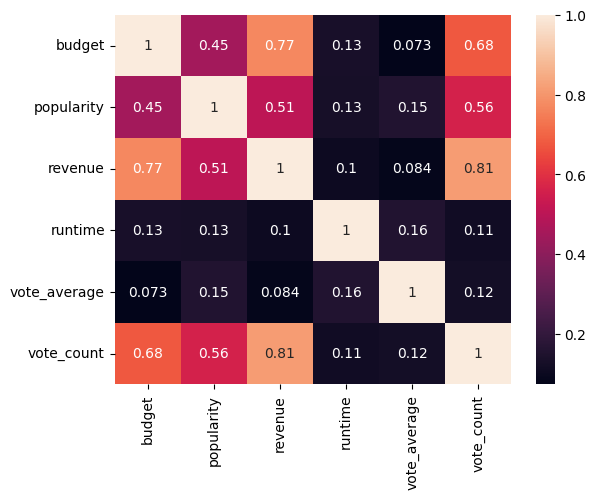

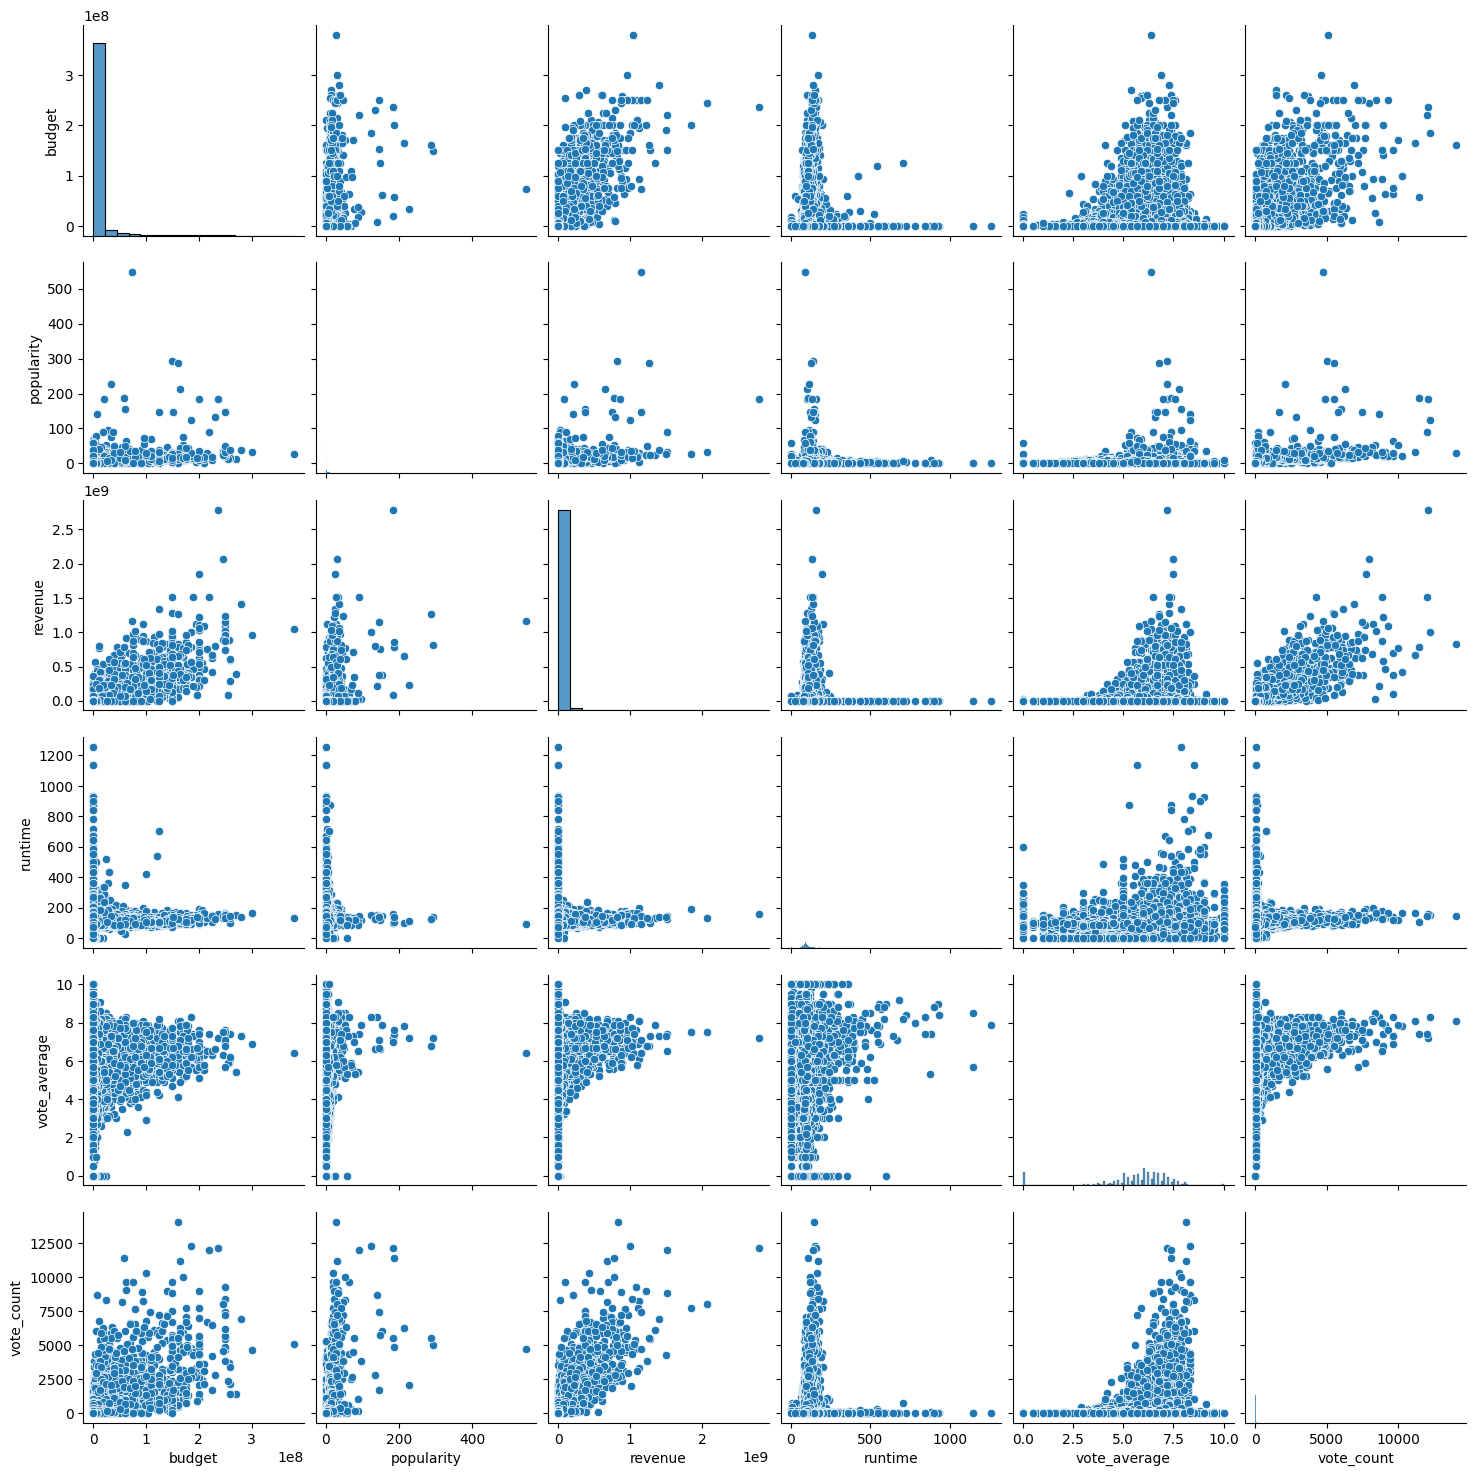

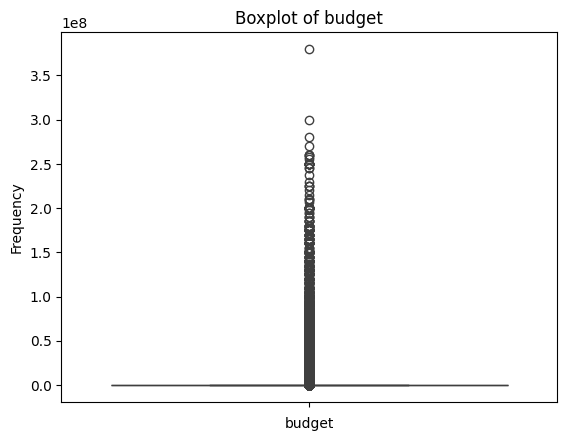

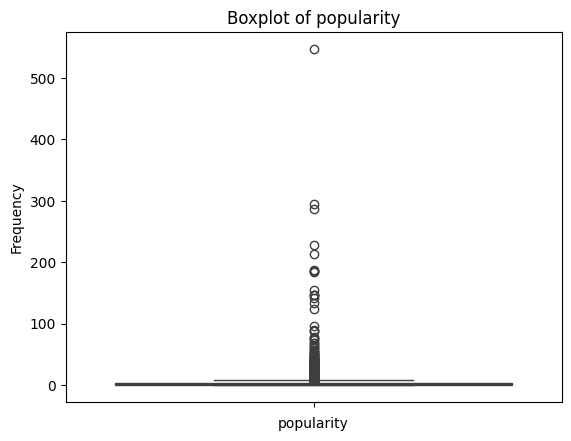

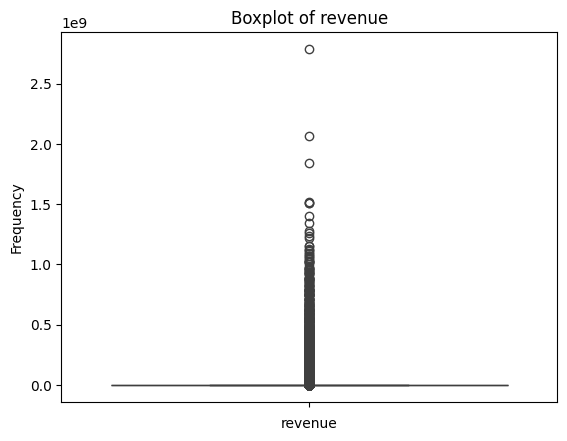

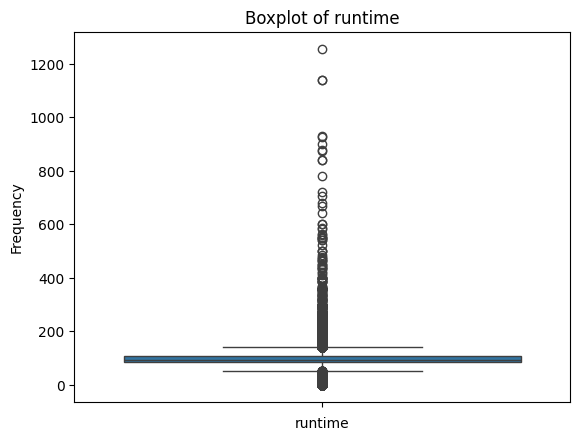

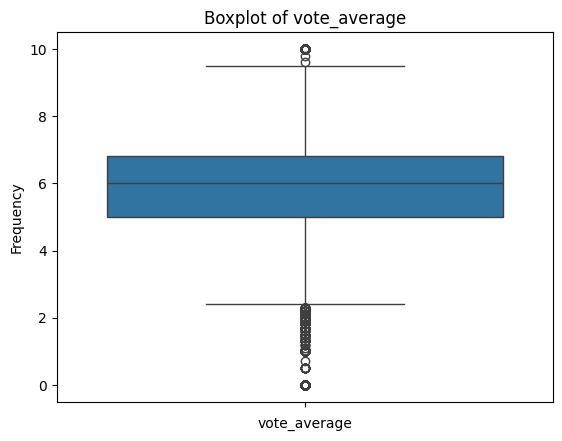

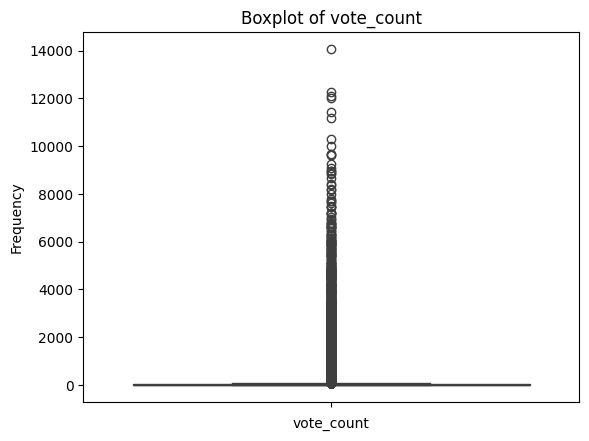

In [95]:
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
categorical_cols = ['genres', 'production_companies_name', 'production_countries_name', 'spoken_languages_name']

### correlation matrix for visualizing possible linearity among numerical attributes
sns.heatmap(movies_metadata_df_copy_imputed[numerical_cols].corr(), annot=True)
plt.show()

### pairlot for numerical attributes
sns.pairplot(movies_metadata_df_copy_imputed[numerical_cols])
plt.show()


### outlier for numerical
for col in numerical_cols:
  sns.boxplot(data=movies_metadata_df_copy_imputed[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'Boxplot of {col}')
  plt.show()


#### Observation for EDA

From the boxplot of the numerical features we can see visible indication of outliers. Hence, we will be using LOF on those features to identify outliers and remove outliers where necessary.




### b. Outlier detection using LOF
Detects outliers from a given dataframe for a specified column.

In [14]:
# func to detect outlier and print
def find_outlier(df, col_name, n_neighbors=2500, contamination=0.5):
  # Scaling the data
  scaler = StandardScaler()
  mileage_scaled = scaler.fit_transform(df[[col_name]])

  # Adjusting LOF parameters
  lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)  # Example adjustment
  outliers = lof.fit_predict(mileage_scaled)
  print( outliers)
  # Check the number of outliers detected
  outlier_count = np.sum(outliers == -1)
  print("Number of outliers detected:", outlier_count)

  # # Visualizing results
  plt.figure(figsize=(20, 10))
  plt.scatter(range(len(df[col_name])), df[col_name], c=outliers, cmap='coolwarm', label='Data Points')
  plt.colorbar()
  plt.title('Outlier Detection in ' + col_name)
  plt.xlabel('Index')
  plt.ylabel(col_name)
  plt.show()
  return outliers



### c. Process/Remove detected outliers
Removes the detected outlier from the dataframe passed to it as parameter and returns a copy of the dataframe.

In [15]:

def remove_outliers_2(df, outlier_list):
  df_removed_outlier = df.copy()
  outlier_indices = [i for i, outlier_flag in enumerate(outlier_list) if outlier_flag == -1]
  # Drop rows using a boolean mask based on outlier indices
  df_removed_outlier = df_removed_outlier[~df_removed_outlier.index.isin(outlier_indices)]

  print('Total rows dropped',len(outlier_indices))
  return df_removed_outlier


## **Feature Engineering**
Since feature Engineering were not adding values to the study, feature engineering was not performed over the any/combination of the attributes.

## **Studies**

### a. Study 1 – Similarity measures

For this study1, similarity measures on different attributes are needed. According to the instructions, a subset of 5 attributes (e.g. Genre, Revenue, Runtime, Title, Budget) were taken from the dataset. Using the subset of attributes different similarity measures (e.g. Jaccard, Hamming, Cosine, Euclidian, Manhattan, edit) were explored. Each similarity measure has been tested with atleast one query. The generated output of the query has been printed in the console better understanding and effectiveness.


In [16]:
# a subset of 5 attributes (e.g. Genre, Revenue, Runtime, Title, Budget) from dataset.
movies_metadata_df_copy_imputed_subset = movies_metadata_df_copy_imputed[['genres','revenue','runtime','title','budget']].copy()
# movies_metadata_df_copy_imputed_subset.head(30)
# movies_metadata_df_copy_imputed_subset.info()


### scale the numeric cols
scaler = MinMaxScaler()
cols_to_scale = ['revenue', 'runtime', 'budget']
movies_metadata_df_copy_imputed_subset[cols_to_scale] = scaler.fit_transform(movies_metadata_df_copy_imputed_subset[cols_to_scale])
movies_metadata_df_copy_imputed_subset.info()
movies_metadata_df_copy_imputed_subset.head(30)


### func to calculate Jaccard similarity
def calculate_jaccard_similarity(row1, row2):
  row_1_set = set(row1)
  row_2_set = set(row2)
  intersection = row_1_set.intersection(row_2_set)
  union = row_1_set.union(row_2_set)
  # print(f"Row1: {row1}, Row2: {row2}, Intersection: {intersection}, Union: {union}")
  return len(intersection) / len(union) if len(union) > 0 else 0


### func to calculate euclidian_similarities
### Returns distance, lower value means more similarity
def calculate_euclidean_similarity(row1, row2):
  # # reshaping dictates there will be 1 row and variable amount of col
  row1 = np.array(row1).reshape(1,-1)
  row2 = np.array(row2).reshape(1,-1)
  return euclidean_distances(row1, row2)[0][0]



### func to calculate manhattan similarity
### returns distance , lower value means more similarity
def calculate_manhattan_similarity(row1, row2):
  row1 = np.array(row1).reshape(1,-1)
  row2 = np.array(row2).reshape(1,-1)
  return manhattan_distances(row1, row2)[0][0]


### pre-procees text for cosine sim
def pre_process_text(text):
  # tolenize/spit the text into word
  tokens = word_tokenize(text.lower())
  # remove punctuation
  tokens = [token for token in tokens if token.isalpha()]
  # remove stopwords
  stop_words = set(stopwords.words('english'))
  tokens = [token for token in tokens if token not in stop_words]
  return tokens




### func to calculate cosine_similarities
###
def calculate_cosine_similarity(row1, row2): # [budget, revenue]
  # pre-process both text
  token1 = pre_process_text(row1)
  token2 = pre_process_text(row2)

  # create a set of all unique token
  all_tokens = set(token1).union(set(token2))

  # create vectors conssiting each text
  vector1 =[token1.count(tok) for tok in all_tokens]
  vector2 =[token2.count(tok) for tok in all_tokens]

  return cosine_similarity([vector1],[vector2])[0][0]


### func to calculate textual similarity (edit distance)
def calculate_edit_similarity(row1, row2):
  return Levenshtein.distance(row1, row2)



##### ----- Request simulation ------#######

### req1: Show me movies of the same genre as “Toy Story”
requested_movie_req1 = 'Toy Story'
requested_movie_genre = movies_metadata_df_copy_imputed_subset[movies_metadata_df_copy_imputed_subset['title'] == requested_movie_req1]['genres'].iloc[0]
# print(requested_movie_genre)
genre_similarities = movies_metadata_df_copy_imputed_subset.apply(lambda row: calculate_jaccard_similarity(requested_movie_genre, row['genres']), axis=1)
# print(genre_similarities)
genre_similarity_df = pd.DataFrame({
    'title': movies_metadata_df_copy_imputed_subset['title'],
    'genres': movies_metadata_df_copy_imputed_subset['genres'],
    'genre_similarity': genre_similarities,
    'runtime': movies_metadata_df_copy_imputed_subset['runtime']
    })
genre_similarity_df = genre_similarity_df.sort_values(by='genre_similarity', ascending=False)
print('Req 1: Movie similar to', requested_movie_req1, 'based on genres:')
print(genre_similarity_df.head(10))


### req2: Show me movies with similar revenue to “Titanic”
requested_movie_req2 = 'Titanic'
requested_movie_revenue = movies_metadata_df_copy_imputed_subset[movies_metadata_df_copy_imputed_subset['title'] == requested_movie_req2]['revenue'].iloc[0]
print(requested_movie_revenue)
revenue_similarities = movies_metadata_df_copy_imputed_subset['revenue'].apply(lambda row: calculate_euclidean_similarity(requested_movie_revenue, row))
revenue_similarity_df = pd.DataFrame({
    'title': movies_metadata_df_copy_imputed_subset['title'],
    'revenue': movies_metadata_df_copy_imputed_subset['revenue'],
    'revenue_similarity': revenue_similarities,
    'runtime': movies_metadata_df_copy_imputed_subset['runtime'],
    'genres': movies_metadata_df_copy_imputed_subset['genres']
    })
revenue_similarity_df = revenue_similarity_df.sort_values(by='revenue_similarity', ascending=False)
print('Req 2: Movie similar to', requested_movie_req2, 'based on revenue:')
print(revenue_similarity_df.head(10))


### req3:Show me movies with similar length as “Apollo 13”
requested_movie_req3 = 'Apollo 13'
requested_movie_runtime = movies_metadata_df_copy_imputed_subset[movies_metadata_df_copy_imputed_subset['title'] == requested_movie_req3]['runtime'].iloc[0]
print(requested_movie_runtime)
runtime_similarities = movies_metadata_df_copy_imputed_subset['runtime'].apply(lambda row: calculate_manhattan_similarity(requested_movie_runtime, row))
runtime_similarity_df = pd.DataFrame({
    'title': movies_metadata_df_copy_imputed_subset['title'],
    'runtime': movies_metadata_df_copy_imputed_subset['runtime'],
    'runtime_similarity': runtime_similarities,
    'revenue': movies_metadata_df_copy_imputed_subset['revenue'],
    'genres': movies_metadata_df_copy_imputed_subset['genres']
    })
runtime_similarity_df = runtime_similarity_df.sort_values(by='runtime_similarity', ascending=False)
print('Req 3: Movie similar to', requested_movie_req3, 'based on runtime:')
print(runtime_similarity_df.head(10))


### Req4:Show me movies with similar title to “Fight Club”
requested_movie_req4 = 'Fight Club'
requested_movie_title = movies_metadata_df_copy_imputed_subset[movies_metadata_df_copy_imputed_subset['title'] == requested_movie_req4]['title'].iloc[0]
print(requested_movie_title)
title_similarities = movies_metadata_df_copy_imputed_subset['title'].astype(str).apply(lambda row: calculate_cosine_similarity(requested_movie_title, row))
title_similarity_df = pd.DataFrame({
    'title': movies_metadata_df_copy_imputed_subset['title'],
    'title_similarity': title_similarities,
    'revenue': movies_metadata_df_copy_imputed_subset['revenue'],
    'runtime': movies_metadata_df_copy_imputed_subset['runtime'],
    'genres': movies_metadata_df_copy_imputed_subset['genres']
    })
title_similarity_df = title_similarity_df.sort_values(by='title_similarity', ascending=False)
print('Req 4: Movie similar to', requested_movie_req4, 'based on title:')
print(title_similarity_df.head(10))


### Req5:Show me movies with similar budget to “Matrix”
requested_movie_req5 = 'The Matrix'
requested_movie_budget = movies_metadata_df_copy_imputed_subset[movies_metadata_df_copy_imputed_subset['title'] == requested_movie_req5]['budget'].iloc[0]
print(requested_movie_budget)
budget_similarities = movies_metadata_df_copy_imputed_subset['budget'].apply(lambda row: calculate_euclidean_similarity(requested_movie_budget, row))
budget_similarity_df = pd.DataFrame({
    'title': movies_metadata_df_copy_imputed_subset['title'],
    'budget': movies_metadata_df_copy_imputed_subset['budget'],
    'budget_similarity': budget_similarities,
    'revenue': movies_metadata_df_copy_imputed_subset['revenue'],
    'runtime': movies_metadata_df_copy_imputed_subset['runtime'],
    'genres': movies_metadata_df_copy_imputed_subset['genres']
    })
budget_similarity_df = budget_similarity_df.sort_values(by='budget_similarity', ascending=False)
print('Req 5: Movie similar to', requested_movie_req5, 'based on budget:')
print(budget_similarity_df.head(10))



##### Req6: compare “Toy Story” with “Sad Story”
req_movie1 = 'Toy Story'
req_movie2 = 'Sad Story'
similarity = calculate_edit_similarity(req_movie1, req_movie2)
print(f'Req6: compare the distance between “Toy Story” with “Sad Story” ')
print(f"Similarity between '{req_movie1}' and '{req_movie2}': {similarity}")




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   45466 non-null  object 
 1   revenue  45466 non-null  float64
 2   runtime  45466 non-null  float64
 3   title    45460 non-null  object 
 4   budget   45466 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.7+ MB
Req 1: Movie similar to Toy Story based on genres:
                                             title  \
6795                  Looney Tunes: Back in Action   
0                                        Toy Story   
40229                             Rabbit Seasoning   
40456                                      Lorenzo   
42235                                The Boss Baby   
1110                            The Wrong Trousers   
8207                                   Bébé's Kids   
8247               The SpongeBob SquarePants Movie   
5627   The Looney, Looney, Looney Bug

### b. Study 2 - Clustering Algorithms

### 2.a. KMeans Clustering

In [17]:
### copy the dataset for kMeans clustering
movies_metadata_df_copy_imputed_subset_2 = movies_metadata_df_copy_imputed_subset.copy()
movies_metadata_df_copy_imputed_subset_2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   45466 non-null  object 
 1   revenue  45466 non-null  float64
 2   runtime  45466 non-null  float64
 3   title    45460 non-null  object 
 4   budget   45466 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.7+ MB


### 2.1. Outliers identification

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


[1 1 1 ... 1 1 1]
Number of outliers detected: 3146


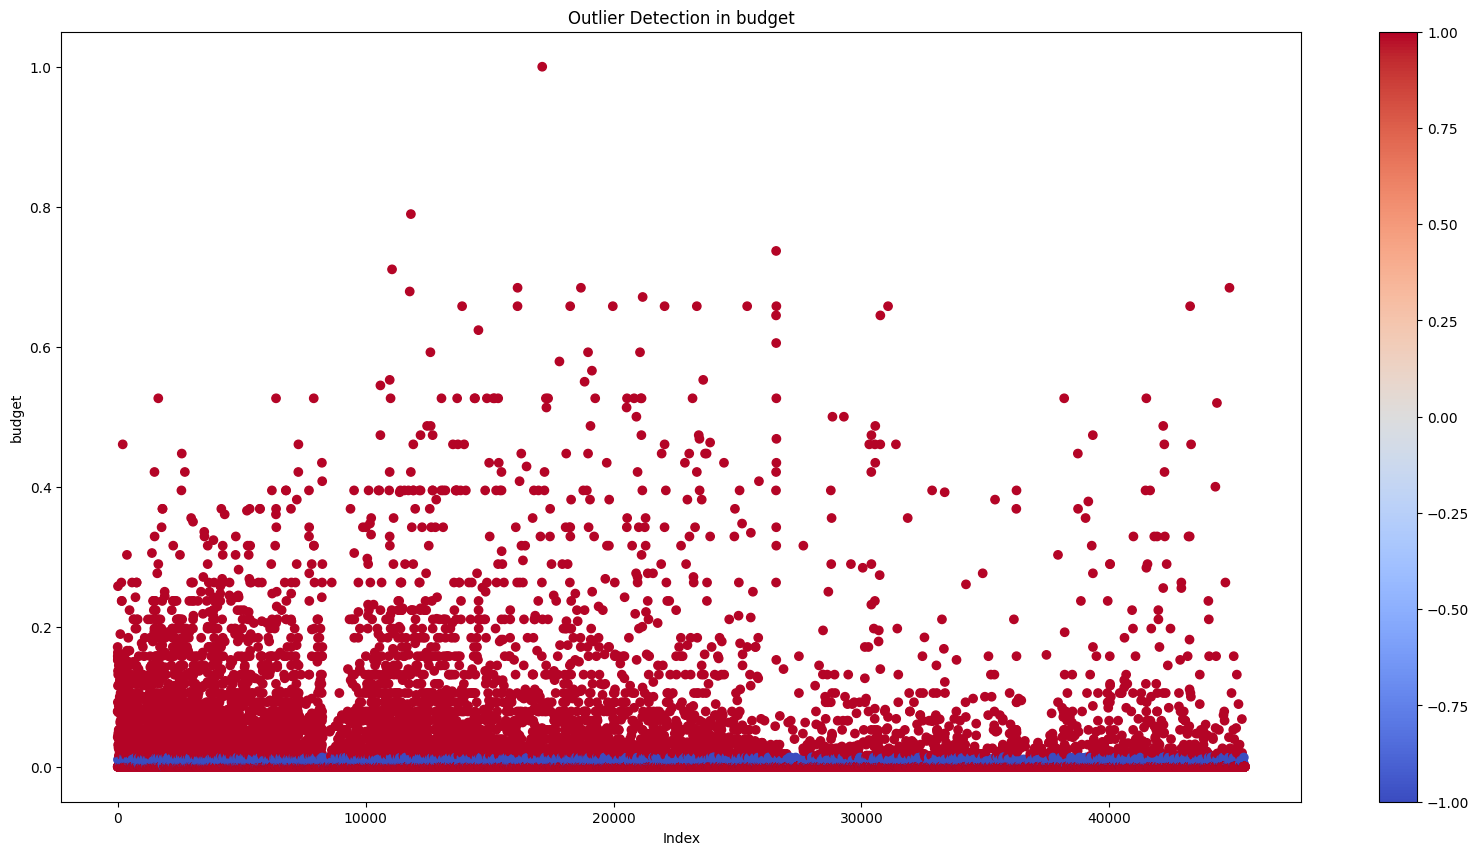

In [18]:
outlier_budget = find_outlier(movies_metadata_df_copy_imputed_subset_2, 'budget', 5000, 0.07)


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


[1 1 1 ... 1 1 1]
Number of outliers detected: 3183


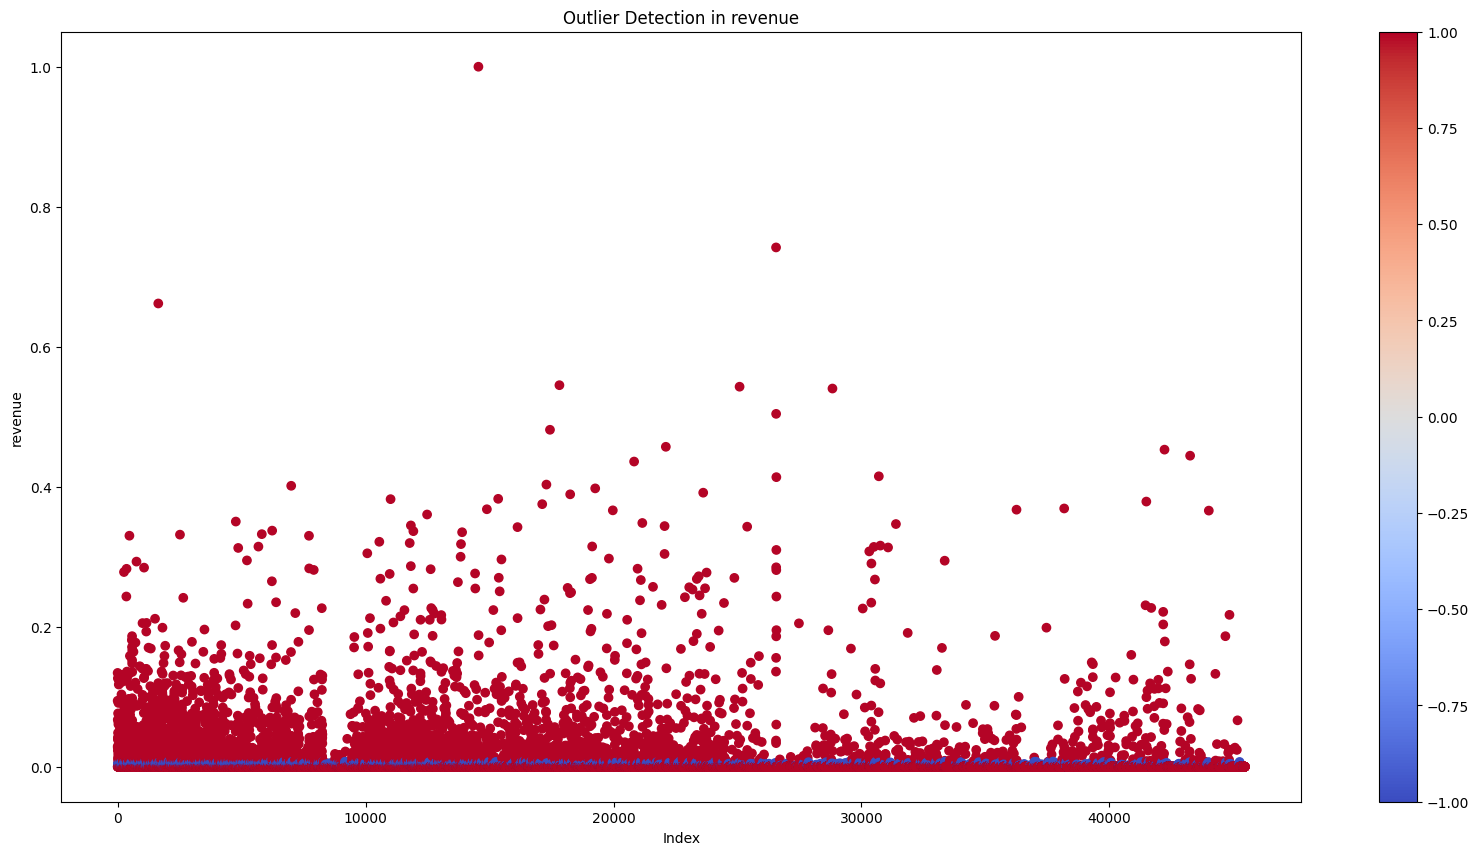

In [19]:
outlier_revenue = find_outlier(movies_metadata_df_copy_imputed_subset_2, 'revenue',5000, 0.07)


[1 1 1 ... 1 1 1]
Number of outliers detected: 2717


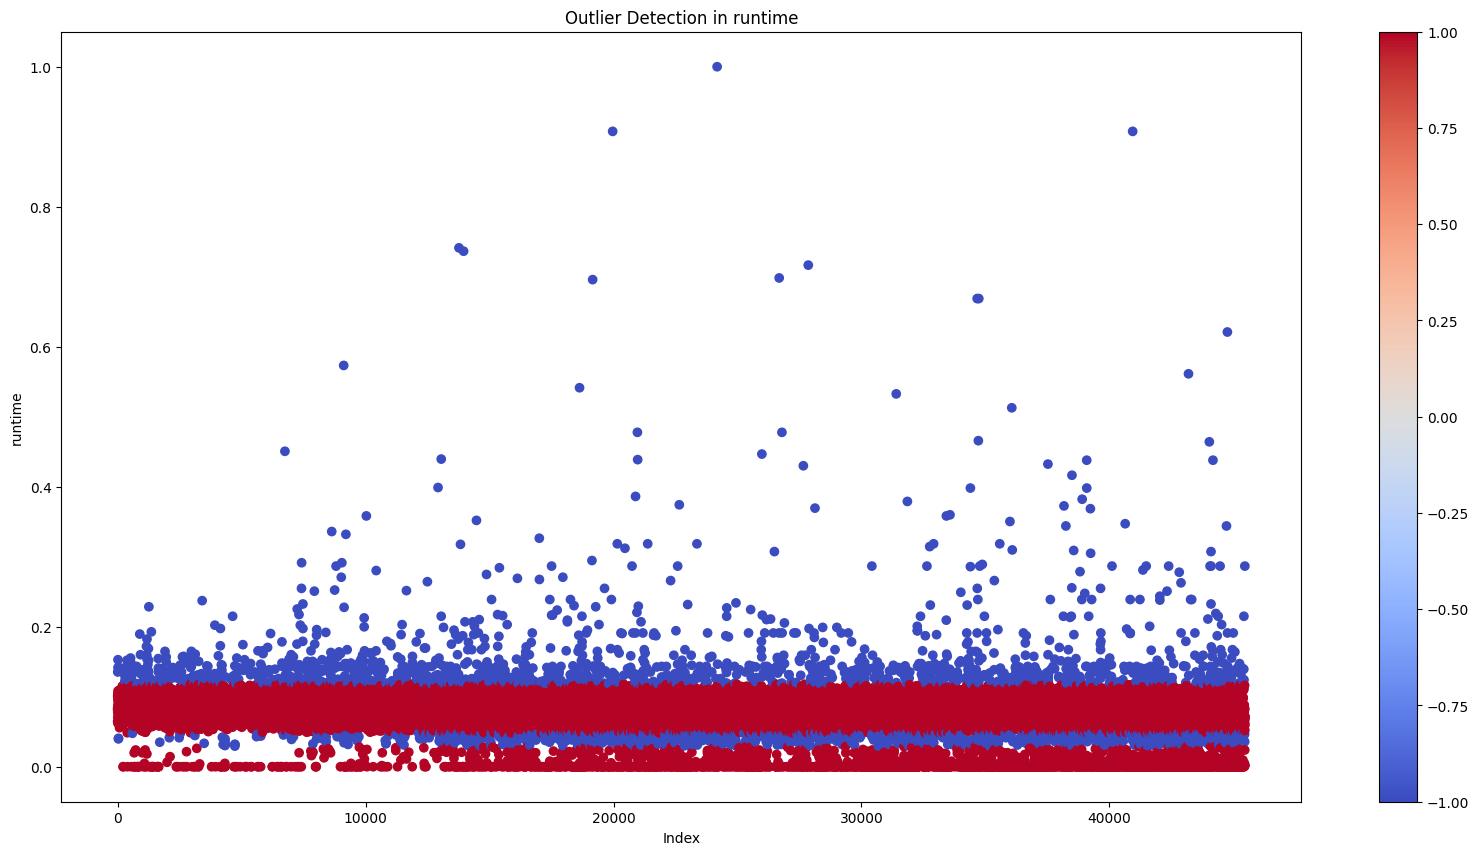

In [20]:
outlier_runtime = find_outlier(movies_metadata_df_copy_imputed_subset_2, 'runtime', 5000, 0.07)

### 2.2. Outliers Removal

In [21]:
### Remove the identified outliers from the atrributes 'budget', 'revenue', 'runtime'
movies_metadata_df_copy_imputed_subset_2.info()

movies_metadata_df_copy_imputed_subset_2 = remove_outliers_2(movies_metadata_df_copy_imputed_subset_2, outlier_budget)
# movies_metadata_df_copy_imputed_subset_2.info()
movies_metadata_df_copy_imputed_subset_2 = remove_outliers_2(movies_metadata_df_copy_imputed_subset_2, outlier_revenue)
# movies_metadata_df_copy_imputed_subset_2.info()
movies_metadata_df_copy_imputed_subset_2 = remove_outliers_2(movies_metadata_df_copy_imputed_subset_2, outlier_runtime)
movies_metadata_df_copy_imputed_subset_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   45466 non-null  object 
 1   revenue  45466 non-null  float64
 2   runtime  45466 non-null  float64
 3   title    45460 non-null  object 
 4   budget   45466 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.7+ MB
Total rows dropped 3146
Total rows dropped 3183
Total rows dropped 2717
<class 'pandas.core.frame.DataFrame'>
Index: 37486 entries, 0 to 45465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   37486 non-null  object 
 1   revenue  37486 non-null  float64
 2   runtime  37486 non-null  float64
 3   title    37480 non-null  object 
 4   budget   37486 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.7+ MB


### 2.3. Find nearly optimal number of cluster using Elbow method

Deciding the number of clusters for any dataset is a tricky task. Thus, for this part of the study the 'elbow method' was used to get an idea of what an optimum number of clusters could be.

The function 'find_optimal_clusters' finds the near optimal number of clusters by plotting the interia values for a range of cluster numbers(k). As the cluster number(k)increases, the data points within a particular cluster become more densed and as a result the interia becomes lower which is expected.

According to the 'elbow method', where the rate of interia decrease against the cluster numbers(k) sharply shifts, can be a good candidate for the choice of number of clusters(k). Because, it suggests that, increasing the cluster number(k) after this point will not improve the model's fit greatly.

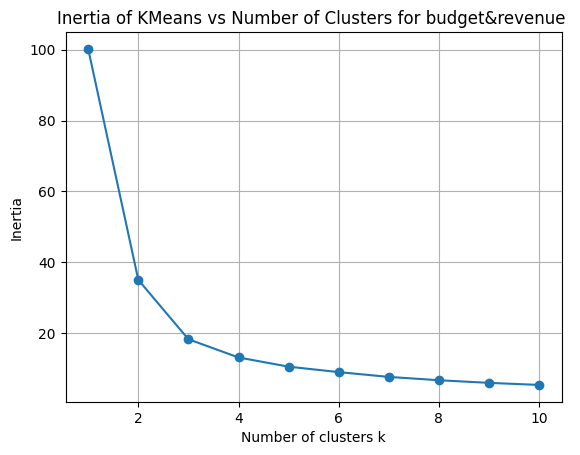

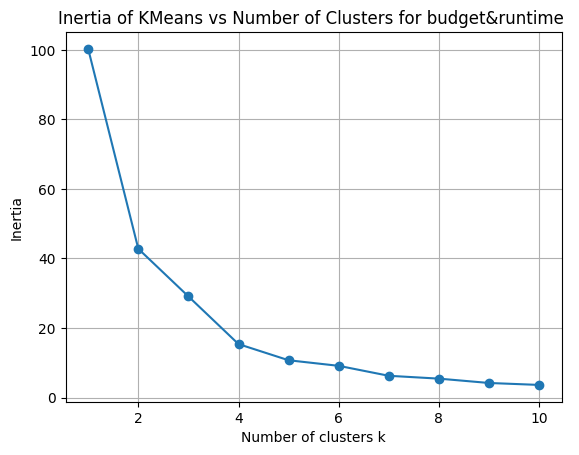

In [22]:
### func to perform kmeans clustering
### this function applies the K-means clustering algorithm
### to the specified dataset for a given number of clusters (n_clusters)
def perform_kmeans_clustering(df,n_clusters):
  model = KMeans(n_clusters=n_clusters, random_state=42)
  kmeans_clusters = model.fit_predict(df)
  return kmeans_clusters, model.inertia_, model.cluster_centers_



### func to decide optimum num of clusters using elbow method
def find_optimal_clusters(df, attribute1, attribute2,max_clusters=9):
  ### Visualizing the interia to decide optimum numner of clusters
  inertias = []
  k_values = range(1, max_clusters + 1)
  for k in k_values:
    _, inertia,_ = perform_kmeans_clustering(movies_metadata_df_copy_imputed_subset_2[[attribute1, attribute2]], k)
    inertias.append(inertia)

  plt.plot(k_values, inertias, marker='o')
  plt.xlabel('Number of clusters k')
  plt.ylabel('Inertia')
  plt.title(f'Inertia of KMeans vs Number of Clusters for {attribute1}&{attribute2} ')
  plt.grid(True)
  plt.show()
  return None

## call the func to find optimal cluster for 'budget' vs 'revenue'
find_optimal_clusters(movies_metadata_df_copy_imputed_subset_2, 'budget', 'revenue', 10)
## call the func to find optimal cluster for 'budget' vs 'runtime'
find_optimal_clusters(movies_metadata_df_copy_imputed_subset_2, 'budget', 'runtime', 10)




#### 2.3. Observation
From the graph, it can be seen that the value of interia decreased sharply when number of clusters(k)=2. Also, the decrease of interia values started to show a steady decrease after k=4. Therefore, we will test the KMeans clustering with k = 2,3,4 and visualize the plots for each k's. Then we can check visually which k makes sense and effectively cluster the datapoints.

### 2.4. Visulization of clusters for k = 2,3,4

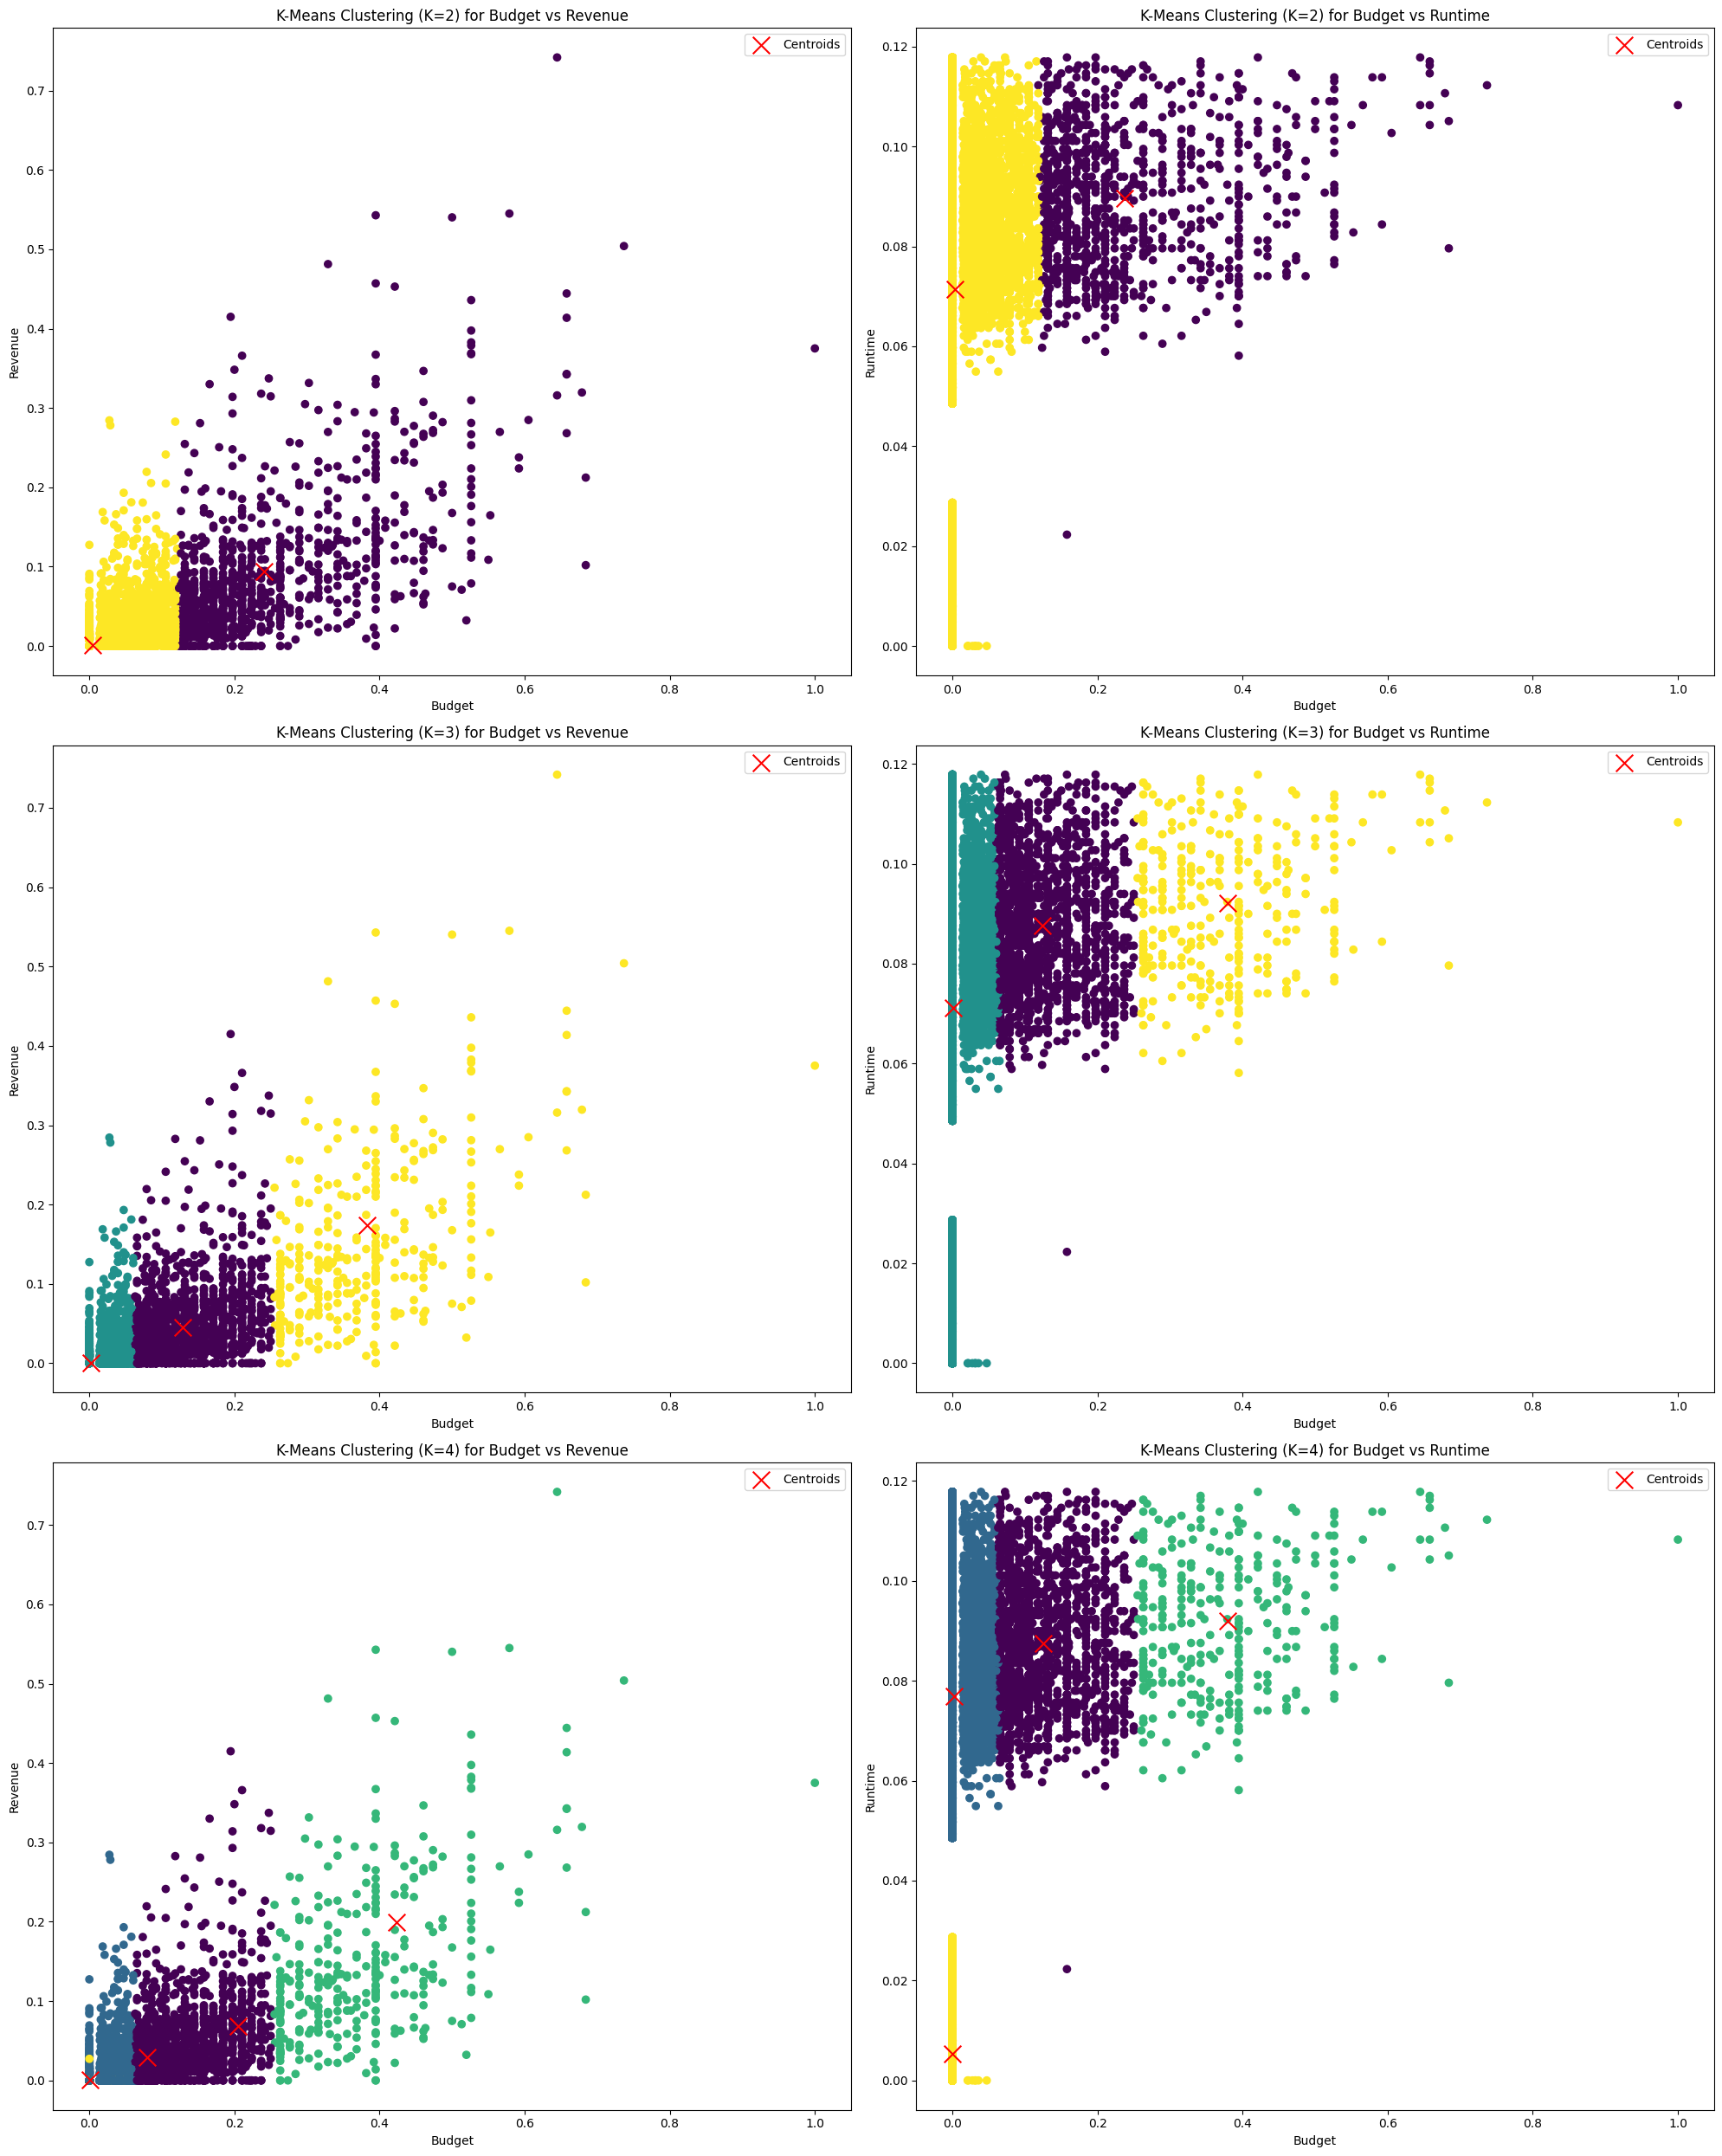

In [23]:

### cluster sizes
k_values = [2,3,4]
### store cluster results
kmeans_results = {}
# store centroids
centroids_budget_revenue = {}
centroids_budget_runtime = {}

### run kmeans on the specified attribute combination for the specified cluster sizes
for k in k_values:
  kmeans_results[f'kmeans_clusters_for_k_{k}'],interia_rev, centroids_budget_revenue[k] = perform_kmeans_clustering(movies_metadata_df_copy_imputed_subset_2[['budget', 'revenue']], k)
  kmeans_results[f'kmeans_clusters_for_k_{k}'],interia_run, centroids_budget_runtime[k] = perform_kmeans_clustering(movies_metadata_df_copy_imputed_subset_2[['budget', 'runtime']], k)
#   print(f'Center for K = {k} on Budget vs Revenue: {centroids_budget_revenue[k]}')
#   print(f'Interia for k = {k} on Budget vs Revenue: {interia_rev}')
#   print(f'Interia for k = {k} on Budget vs Runtime: {interia_run}')
# print(kmeans_results)


### visulaize the clusters after kmeans
fig, plt.axes = plt.subplots( len(k_values), 2, figsize=(20, 25))

for i, k in enumerate(k_values):
  ## revenue vs budget
  plt.axes[i, 0].scatter(movies_metadata_df_copy_imputed_subset_2['budget'], movies_metadata_df_copy_imputed_subset_2['revenue'], c=kmeans_results[f'kmeans_clusters_for_k_{k}'])
  # Plot centroids for budget vs revenue
  plt.axes[i, 0].scatter(centroids_budget_revenue[k][:, 0], centroids_budget_revenue[k][:, 1], marker='x', s=200, c='red', label='Centroids')
  plt.axes[i, 0].set_xlabel('Budget')
  plt.axes[i, 0].set_ylabel('Revenue')
  plt.axes[i, 0].set_title(f'K-Means Clustering (K={k}) for Budget vs Revenue')
  plt.axes[i, 0].legend()

  ## budget vs runtime
  plt.axes[i, 1].scatter(movies_metadata_df_copy_imputed_subset_2['budget'], movies_metadata_df_copy_imputed_subset_2['runtime'], c=kmeans_results[f'kmeans_clusters_for_k_{k}'])
  # plt centroid for budget vs runtime
  plt.axes[i, 1].scatter(centroids_budget_runtime[k][:, 0], centroids_budget_runtime[k][:, 1], marker='x', s=200, c='red', label='Centroids')
  plt.axes[i, 1].set_xlabel('Budget')
  plt.axes[i, 1].set_ylabel('Runtime')
  plt.axes[i, 1].set_title(f'K-Means Clustering (K={k}) for Budget vs Runtime')
  plt.axes[i, 1].legend()

plt.tight_layout()
plt.show()




#### 2.4. Observation from the clusters
For the 'budget' vs 'revenue' clustering, k=3 seemed to be a good choice among the three. Beacuse, k=3 generates a plot that provides a useful data point segmentation; showing distinct and reasonablely separated clusters without excessive segmentations.


For the 'budget' vs 'runtime' clustering, k=2,3 both seemed to be a good choice among the three. Both generates a plot that provides a useful data point segmentation; showing distinct and reasonablely separated clusters without excessive segmentations. However, if more precise segmentation according to runtime categories/range is needed k=3 seems to the best value for k. One can choose k's value between 2 or 3 depending on the need of the study.

### 2.b. DBSCAN Clustering
For DBSCAN clustering, we will experiment with 2 different values for each eps and min_samples. Total we will have 8 different combination and corresponding plot for each of the combination.

**Note:** For the DBSCAN clustering, the first 30000 data points were used. After identifying the outliers and removing the identified outliers, the data set had approximately 37486 rows. However, whenever tried to go beyond the 30000 samples, colab would crash. Therefore, only 30000 samples were used for DBSCAN clustering.

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 0 to 36636
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   30000 non-null  object 
 1   revenue  30000 non-null  float64
 2   runtime  30000 non-null  float64
 3   title    29994 non-null  object 
 4   budget   30000 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.4+ MB
{'dbscan_clusters_eps_0.3_min_samples_10_bud_rev': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.3_min_samples_10_bud_run': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.3_min_samples_5_bud_rev': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.3_min_samples_5_bud_run': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.5_min_samples_10_bud_rev': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.5_min_samples_10_bud_run': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan_clusters_eps_0.5_min_samples_5_bud_rev': array([0, 0, 0, ..., 0, 0, 0]), 'dbscan

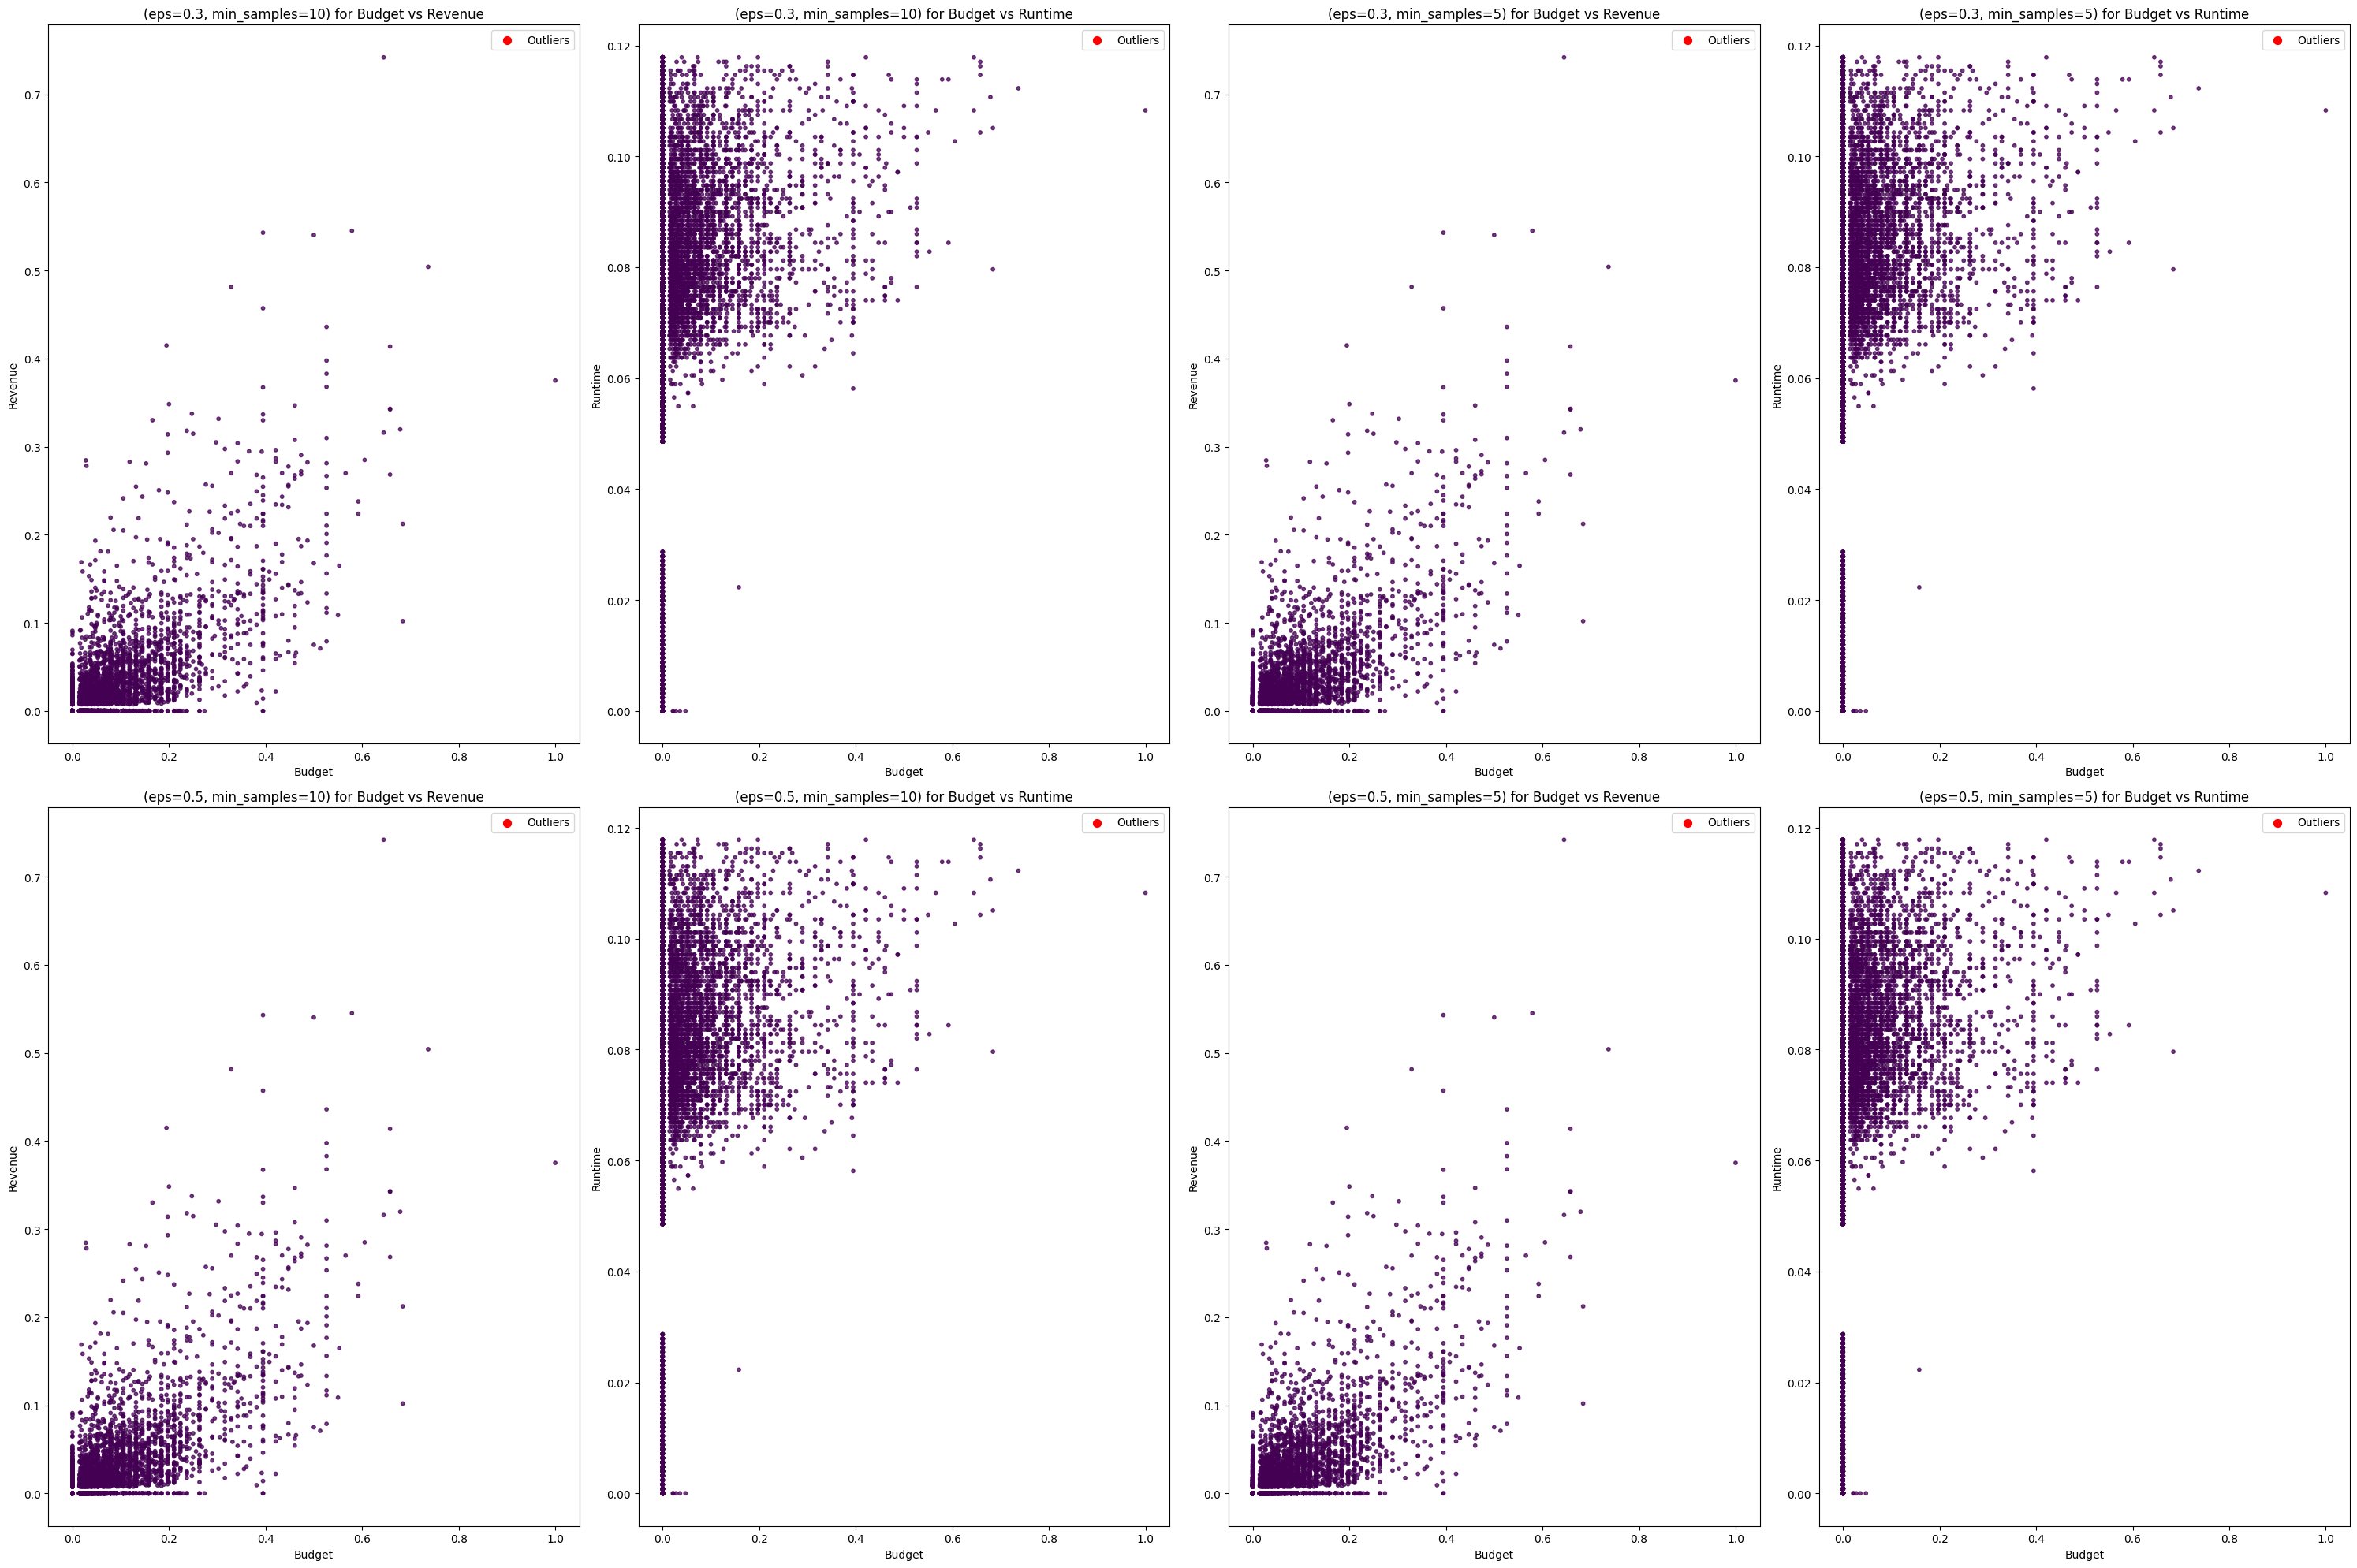

In [24]:
### func to perform DBSCAN clustering on the specified dataset
def perform_dbscan_clustering(df, eps, min_samples, algorithm ='auto'):
  model = DBSCAN(eps=eps, min_samples=min_samples,algorithm=algorithm)
  dbscan_clusters = model.fit_predict(df)
  return dbscan_clusters, model


### Taking the first 30000 samples for the DBSCAN clustering to avoid runtime crash due to system constraints
data_subset = movies_metadata_df_copy_imputed_subset_2[:30000]  ### 40000 crashed. # 30000 was ok
data_subset.info()

eps_values = [0.3,0.5]
min_samples_values = [10,5]
algorithim_type = 'ball_tree'
dbscan_results = {}
for eps in eps_values:
  for min_sample in min_samples_values:
    key_rev = f'dbscan_clusters_eps_{eps}_min_samples_{min_sample}_bud_rev'
    key_run = f'dbscan_clusters_eps_{eps}_min_samples_{min_sample}_bud_run'
    dbscan_results[key_rev], model_bud_rev = perform_dbscan_clustering(data_subset[['budget', 'revenue']], eps, min_sample, algorithim_type)
    dbscan_results[key_run] ,model_bud_run = perform_dbscan_clustering(data_subset[['budget', 'runtime']], eps, min_sample,algorithim_type)

# print(dbscan_results)



### Visualization of Clusters
fig, axes = plt.subplots(len(eps_values), len(min_samples_values) * 2, figsize=(30, 20))  # Adjust the size as needed

for i, eps in enumerate(eps_values):
    for j, min_sample in enumerate(min_samples_values):
        key_rev = f'dbscan_clusters_eps_{eps}_min_samples_{min_sample}_bud_rev'
        key_run = f'dbscan_clusters_eps_{eps}_min_samples_{min_sample}_bud_run'

        # Labels for the current configuration
        labels_rev = dbscan_results[key_rev]
        labels_run = dbscan_results[key_run]

        # Core and outlier mask creation
        core_samples_mask_rev = np.zeros_like(labels_rev, dtype=bool)
        core_samples_mask_rev[model_bud_rev.core_sample_indices_] = True
        outliers_mask_rev = labels_rev == -1

        core_samples_mask_run = np.zeros_like(labels_run, dtype=bool)
        core_samples_mask_run[model_bud_run.core_sample_indices_] = True
        outliers_mask_run = labels_run == -1

        # Plot for Budget vs Revenue
        ax1 = axes[i, 2 * j]  # Corrected index for Budget vs Revenue
        ax1.scatter(data_subset.loc[~outliers_mask_rev, 'budget'], data_subset.loc[~outliers_mask_rev, 'revenue'], c=labels_rev[~outliers_mask_rev], cmap='viridis', s=10, alpha=0.75)
        ax1.scatter(data_subset.loc[outliers_mask_rev, 'budget'], data_subset.loc[outliers_mask_rev, 'revenue'], c='red', label='Outliers', s=50)
        ax1.set_xlabel('Budget')
        ax1.set_ylabel('Revenue')
        ax1.set_title(f'(eps={eps}, min_samples={min_sample}) for Budget vs Revenue')
        ax1.legend()

        # Plot for Budget vs Runtime
        ax2 = axes[i, 2 * j + 1]  # Corrected index for Budget vs Runtime
        ax2.scatter(data_subset.loc[~outliers_mask_run, 'budget'], data_subset.loc[~outliers_mask_run, 'runtime'], c=labels_run[~outliers_mask_run], cmap='viridis', s=10, alpha=0.75)
        ax2.scatter(data_subset.loc[outliers_mask_run, 'budget'], data_subset.loc[outliers_mask_run, 'runtime'], c='red', label='Outliers', s=50)
        ax2.set_xlabel('Budget')
        ax2.set_ylabel('Runtime')
        ax2.set_title(f'(eps={eps}, min_samples={min_sample}) for Budget vs Runtime')
        ax2.legend()

plt.tight_layout()
plt.show()




#### 2.b. DBSCAN Clustering Observation

From the generated plot of DBSCAN clustering, it can be seen that adjusting 'eps' and 'min_samples' dramatically influences the number of outliers and the density of the core clusters.

With smaller eps values (top row), the clusters are tighter, but more data points are considered outliers, especially when 'min_samples' is higher. This indicates a stringent condition for forming clusters, resulting in many points not being part of any cluster.

On the other hand, with larger 'eps' values (bottom row) result in fewer outliers and more inclusive clustering, showing that a looser distance criterion allows more points to be considered part of clusters.

Additionally, increasing 'min_samples' typically increases the number of outliers because more points are required to form a dense region. This is evident when comparing the left-most and right-most columns of each feature set (Budget vs Revenue, Budget vs Runtime), where the right-most has fewer points classified as outliers due to a lower min_samples.

### 2.c. Comparison of KMeans and DBSCAN clustering
When compare the two plots generated by the two differnt clustering algorithm the following insights can be drawn:

K-Means provides clear, well-defined clusters with every point assigned to a cluster. This method is effective in dividing the data into visually distinct groups based on average distances, which is useful for straightforward segmentation tasks.

DBSCAN reveals the data's density structure, identifying core areas of high density and outliers. This method is better for understanding complex structures in data where clusters might not be spherical or evenly sized, and for identifying points that do not fit well with any group.

### c. Study 3 - Content-Based Recommendation System



In [25]:
### copy the dataset for kMeans clustering
movies_metadata_df_copy_imputed_subset_3 = movies_metadata_df_copy_imputed_subset.copy()
movies_metadata_df_copy_imputed_subset_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   genres   45466 non-null  object 
 1   revenue  45466 non-null  float64
 2   runtime  45466 non-null  float64
 3   title    45460 non-null  object 
 4   budget   45466 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.7+ MB


### 3.1. Heuristic 1: Combined Genre and Runtime Similarity
Use Jaccard similarity for genres and Euclidean distance for runtime. This heuristic would give more weight to 'genre' similarity than 'runtime' similarity because genre seems to be a stronger determinant of user preferences in movies than runtime. Runtime for most of the movie is standard. Thus, we will put more more emphasis on 'genre' which has better possibility of adding value to the recommendadtion based on similarity.

In [26]:
### func to test heuristic1 (combination of genre and runtime)
def huristic1_similarity(movie_title, df):
  req_movie_genre = df[df['title'] == movie_title]['genres'].iloc[0]
  req_movie_runtime = df[df['title'] == movie_title]['runtime'].iloc[0]

  genre_similarities = df['genres'].apply(lambda row: calculate_jaccard_similarity(req_movie_genre, row))
  runtime_similarities = df['runtime'].apply(lambda row: calculate_euclidean_similarity(req_movie_runtime, row))
  combined_similarities = 0.67 * genre_similarities + 0.4 * runtime_similarities
  similarity_df = pd.DataFrame({
      'title': df['title'],
      'genre_similarity': genre_similarities,
      'runtime_similarity': runtime_similarities,
      'combined_similarity':combined_similarities
      })
  similarity_df = similarity_df.sort_values(by='combined_similarity', ascending=False)
  return similarity_df

### 3.2. Heuristic 2: Combined Title and Budget Similarity

Use Cosine similarity for 'title' and Euclidean distance for 'budget'. This heuristic would give more weight to 'title' similarity than 'budget' similarity because 'title' seems to be a stronger determinant of user preferences in movies than 'budget'. Budget for many of the  movies is can be similar. Thus, we will put more more emphasis on 'tilte' which has better possibility of adding value to the recommendation based on similarity.



In [27]:
### func to test heuristic2 (combination of title and budget)
def huristic2_similarity(movie_title, df):
  req_movie_title = df[df['title'] == movie_title]['title'].iloc[0]
  req_movie_budget = df[df['title'] == movie_title]['budget'].iloc[0]
  title_similarities = df['title'].astype(str).apply(lambda row: calculate_cosine_similarity(req_movie_title, row))
  budget_similarities = df['budget'].apply(lambda row: calculate_euclidean_similarity(req_movie_budget, row))
  combined_similarities = 0.77 * title_similarities + 0.4 * budget_similarities
  similarity_df = pd.DataFrame({
      'title': df['title'],
      'title_similarity': title_similarities,
      'budget_similarity': budget_similarities,
      'combined_similarity':combined_similarities
      })
  similarity_df = similarity_df.sort_values(by='combined_similarity', ascending=False)
  return similarity_df

### 3.3. Simulate requests and display result

In [28]:
# from warnings import simplefilter
req_movies = ['Toy Story', 'Apollo 13', 'Fight Club']
for movie in req_movies:
  print(f"\n######## Recommendations for '{movie} ########':")
  ## heuristic 1
  similarity_df_h1 = huristic1_similarity(movie, movies_metadata_df_copy_imputed_subset_3)
  print("\nHeuristic 1 (Genre and Runtime):")
  print(similarity_df_h1[['title', 'genre_similarity', 'runtime_similarity', 'combined_similarity']].head(10))


  ## heuristic 2
  similarity_df_h2 = huristic2_similarity(movie, movies_metadata_df_copy_imputed_subset_3)
  print("\nHeuristic 2 (Title and Budget):")
  print(similarity_df_h2[['title', 'title_similarity', 'budget_similarity', 'combined_similarity']].head(10))


######## Recommendations for 'Toy Story ########':

Heuristic 1 (Genre and Runtime):
                             title  genre_similarity  runtime_similarity  \
28985              Superstar Goofy               1.0            0.064490   
45254     Minions: Orientation Day               1.0            0.061306   
45136                       Banana               1.0            0.061306   
40456                      Lorenzo               1.0            0.060510   
38109  Hammy's Boomerang Adventure               1.0            0.060510   
22855        Dug's Special Mission               1.0            0.060510   
3309             Creature Comforts               1.0            0.060510   
44691               Devil May Hare               1.0            0.058917   
40229             Rabbit Seasoning               1.0            0.058917   
30693                  Rabbit Fire               1.0            0.058917   

       combined_similarity  
28985             0.695796  
45254             0

### 3.4. Observation
From the output of heuristics function (heuristic1_similarity and heuristic2_similarity), it can be seen that the output do not provide any evidence of preferences one over the other.

The function 'heuristic1_similarity' prioritizes 'genre' more than 'runtime' and seems to perform well
in identifying movies that are similar in 'genre' to the target movie. However, this recommendation can make users  restrictive if one is looking for variety.

On the other hand, the function 'heuristic2_similarity' prioritizes 'title' more than 'budget' and seems to perform well
in identifying movies that are similar in 'title' to the target movie.However, title similarity might not always be indicative of content similarity, which can lead to irrelevant recommendations if the titles are coincidentally similar but the content is not.


### c.5. One more heuristic combining Title and Genre (heuristic3_similarity)

In [30]:
### func to test heuristic3 (combination of title and genre)
def heuristic3_similarity(movie_title, df):
  req_movie_genre = df[df['title'] == movie_title]['genres'].iloc[0]
  req_movie_title = df[df['title'] == movie_title]['title'].iloc[0]
  genre_similarities = df['genres'].apply(lambda row: calculate_jaccard_similarity(req_movie_genre, row))
  title_similarities = df['title'].astype(str).apply(lambda row: calculate_cosine_similarity(req_movie_title, row))
  combined_similarities = 0.67 * genre_similarities + 0.4 * title_similarities
  similarity_df = pd.DataFrame({
      'title': df['title'],
      'genre_similarity': genre_similarities,
      'title_similarity': title_similarities,
      'combined_similarity':combined_similarities
      })
  similarity_df = similarity_df.sort_values(by='combined_similarity', ascending=False)
  return similarity_df


req_movies = ['Toy Story', 'Apollo 13', 'Fight Club']
for movie in req_movies:
  print(f"\nRecommendations for '{movie}':")
  ## heuristic 3
  similarity_df_h3 = heuristic3_similarity(movie, movies_metadata_df_copy_imputed_subset_3)
  print("\nHeuristic 1 (Genre and Runtime):")
  print(similarity_df_h3[['title', 'genre_similarity', 'title_similarity', 'combined_similarity']].head(10))



Recommendations for 'Toy Story':

Heuristic 1 (Genre and Runtime):
                                           title  genre_similarity  \
15348                                Toy Story 3          1.000000   
0                                      Toy Story          1.000000   
2997                                 Toy Story 2          1.000000   
21928                       Toy Story of Terror!          1.000000   
4799                                     The Toy          0.666667   
25800                 Toy Story That Time Forgot          0.666667   
24319                     Moomins on the Riviera          1.000000   
24262  Bugs Bunny's 3rd Movie: 1001 Rabbit Tales          1.000000   
41906    Scary Godmother: Halloween Spooktakular          1.000000   
42235                              The Boss Baby          1.000000   

       title_similarity  combined_similarity  
15348          1.000000             1.070000  
0              1.000000             1.070000  
2997           1.000

#### c.4. Observation of heuristic3 (Combination of Title and Genre)

From the output, we can see that there are still some variability for the recommendation with this heuristic. However, if we consider the overall performance of content based recommendation this heuristic is capable of recommending most relavant movies. Because, 'genre' directly reflects the themes and style of a movie and 'title' often gives clues about the movie's subject matter. Since this heuristic is more semanticaly aligned with target topic, this is supposed to be the best performing recommender among the 3.

### d. Study 4 – Collaborative Filtering Recommendation System


### d.1. Utility Matrix


In [61]:
ratings_df.info()

### create a pivot table to represent utility matrix
utility_tabular_df = ratings_df.pivot_table(index='userId', columns='movieId', values='rating')
utility_tabular_df.info()
# print(utility_tabular_df.columns[9065])

### fill 'NaN' with numeric 0 for values inside the utility 'matrix utility_tabular_df'
utility_tabular_df.fillna(0, inplace=True)
### convert the pivot table into numpy matrix
utility_matrix = utility_tabular_df.to_numpy()
# print(len(utility_matrix[0]))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
Index: 671 entries, 1 to 671
Columns: 9066 entries, 1 to 163949
dtypes: float64(9066)
memory usage: 46.4 MB


### d.2. Matrix Factorization


In [62]:
def matrix_factorization(utility_matrix, P, Q, K, steps=50, alpha=0.0002, beta=0.02):
    '''
      utility_matrix: rating matrix
      P: User features matrix, each row represents a person
      Q: Item features matrix; each row represents a movie
      K: latent features->hidden features
      steps: iterations
      alpha: learning rate
      beta: regularization parameter'''
    ### transpose the item(movie) feature matris for easy calc
    Q = Q.T
    ### main loop
    for step in range(steps):
       ### iterate over all users and movies in the utility matrix
        for i in range(len(utility_matrix)):
            for j in range(len(utility_matrix[i])):
              if utility_matrix[i][j] > 0: ## only consider non zero entries for error calc
                eij = utility_matrix[i][j] - np.dot(P[i,:],Q[:,j]) # calculate error
                for k in range(K):
                  P[i][k] = P[i][k] + alpha * (2 * eij * Q[k][j] - beta * P[i][k]) # update user matrix
                  Q[k][j] = Q[k][j] + alpha * (2 * eij * P[i][k] - beta * Q[k][j]) # update the item matrix
        # ### reconstruct the predicted matrix
        # r_hat = np.dot(P,Q)

        ### calculate total error for convergence check
        total_error = 0
        for i in range(len(utility_matrix)):  # iterate through users
            for j in range(len(utility_matrix[i])):  #iterate through items
              if utility_matrix[i][j] > 0:
                total_error = total_error + pow(utility_matrix[i][j] - np.dot(P[i,:],Q[:,j]), 2)   # calculate squared error
                for k in range(K):
                  total_error = total_error + (beta/2) * (pow(P[i][k],2) + pow(Q[k][j],2))
        #print(f'Step: {step} and error:{total_error}')
        if total_error < 0.0010:    # convergence check thershold
          break
    return P, Q.T


### initialize params for matrix factorization
latent_features = 2
users_size = len(utility_matrix)   # row represent users
items_size = len(utility_matrix[0]) # col represent individual item(movie)
user_matrix = np.random.rand(users_size, latent_features)
item_matrix= np.random.rand(items_size, latent_features)

### perform matrix factorization on the 'utility_matrix'
user_matrix, item_matrix = matrix_factorization(utility_matrix, user_matrix, item_matrix, latent_features)
print(user_matrix)
print(item_matrix)

### reconstract the preicted matrix
predicted_matrix = np.dot(user_matrix, item_matrix.T)
print(predicted_matrix)


[[0.73280249 0.63404904]
 [1.99690409 1.35123409]
 [1.79586    1.33372098]
 ...
 [1.67753811 1.41620856]
 [1.11578718 1.75002131]
 [1.89286981 1.84254841]]
[[1.0448563  1.10823255]
 [0.72855523 1.1248187 ]
 [1.010368   0.75887297]
 ...
 [0.52921946 0.38031343]
 [0.99406994 0.34142595]
 [0.57920419 0.69394574]]
[[1.46834708 1.2470773  1.22156286 ... 0.62895071 0.94493773 0.8644379 ]
 [3.58395941 2.97474829 3.04302301 ... 1.57069299 2.44640872 2.09429835]
 [3.35448863 2.80857749 2.82660427 ... 1.45763607 2.2405774  1.96569962]
 ...
 [3.32227468 2.81515703 2.76965321 ... 1.42638896 2.15112056 1.95440899]
 [3.10526784 2.78136928 2.45539952 ... 1.25605291 1.70667319 1.86068844]
 [4.01974906 3.4515931  3.31075526 ... 1.70248946 2.51073883 2.37498673]]


### d.3. Model based Recommender


In [63]:
print(predicted_matrix.shape)
### func to recommend to user based on user ratings (collaborative filtering)
def get_recommendations1(user_id, utility_matrix, predicted_matrix, num_recommendations=5):
  ### retrive the predicted ratings for the user with 'user_id'
  user_idx = user_id - 1
  ### retrive the predicted rating for given user_id
  pred_ratings = predicted_matrix[user_idx].copy()
  #print('pred ratings type:',pred_ratings.shape)

  ### get the movies the user with provided id has already rated
  already_rated_movies = np.where(utility_matrix[user_idx] > 0)[0]

  #print(f'already rated movies{already_rated_movies}')
  ### set -inf the already rated movies from the predicted ratings so that they can not be recommended
  pred_ratings[already_rated_movies] = -np.inf

  #print(f'Predicted ratings after removing already rated movies: {pred_ratings[833]}')
  ### sort the predicted ratings in descending order
  sorted_indices = np.argsort(pred_ratings)[::-1]
  #print(f'sorted indices{sorted_indices}')
  ### get top rated movie indices
  top_rated_movie_indices = sorted_indices[:num_recommendations]
  #print(f'Top rated movie indices for user {user_id}: {top_rated_movie_indices}')

  ### get the the movies id corresponding to the top rated indices
  recommended_movie_ids = []
  for movie_idx in top_rated_movie_indices:
    recommended_movie_ids.append(utility_tabular_df.columns[movie_idx])
  return recommended_movie_ids



### simulate 3 request for 3 users
user_ids = [1, 12, 4]
for user_id in user_ids:
  collaborative_recommendation = get_recommendations1(user_id, utility_matrix, predicted_matrix)
  print(f'Recommended movies for user {user_id}:')
  for movie_id in collaborative_recommendation:
    print(f'{movie_id}')



(671, 9066)
Recommended movies for user 1:
318
296
858
608
1221
Recommended movies for user 12:
318
50
527
858
912
Recommended movies for user 4:
318
1172
608
1221
50


### d.4. Evaluation

### d.1. Quantitative Evaluation (MSE, P@k, MRR)

In [64]:
### Set the seed for reproducibility
np.random.seed(42)

### split the dataset into train_data and gs_data(test_data)
ratings_df_copy = ratings_df.copy()

### sample 10% of the datafor gold standard
gs_indices = np.random.choice(ratings_df_copy.index, size=int(0.1 * len(ratings_df_copy)), replace=False)
#print(gs_indices.shape)


### retrive the data rows for the gs_indices
gs_data = ratings_df_copy.iloc[gs_indices]

## set ratings as 0 for the sampled data 'gs_indices' in the dataset
## so that this indices can be compared with the actual and the predicted values
ratings_df_copy.loc[gs_indices, 'rating'] = 0


### create a new utility matrix with only train data set
train_utility_tabular_df = ratings_df_copy.pivot_table(index='userId', columns='movieId', values='rating')
train_utility_tabular_df.fillna(0, inplace=True)
train_utility_matrix = train_utility_tabular_df.to_numpy()

### initialize the params for matrix factorization
latent_features = 2
users_size_train = len(train_utility_matrix)   # row represent users
items_size_train = len(train_utility_matrix[0]) # col represent individual item(movie)
user_matrix_train = np.random.rand(users_size_train, latent_features)
item_matrix_train= np.random.rand(items_size_train, latent_features)

### perform matrix factorization on the train dataset
user_matrix_train, item_matrix_train = matrix_factorization(train_utility_matrix, user_matrix_train, item_matrix_train, latent_features)

### reconstruct the predicted matrix
predicted_matrix_train = np.dot(user_matrix_train, item_matrix_train.T)


### MSE calculation
actual_ratings = []
predicted_ratings = []

for _, row in gs_data.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    actual_rating = row['rating']
    ## retrive the predicted ratings from the '
    predicted_rating = predicted_matrix_train[train_utility_tabular_df.index.get_loc(user_id), train_utility_tabular_df.columns.get_loc(movie_id)]
    #print(f'user_id: {user_id}, movie_id: {movie_id}, actual_rating: {actual_rating}, predicted_rating: {predicted_rating}')
    actual_ratings.append(actual_rating)
    predicted_ratings.append(predicted_rating)

mse = mean_squared_error(np.array(predicted_ratings), np.array(actual_ratings))
print(f'Mean Squared Error (MSE): {mse}')





Mean Squared Error (MSE): 1.158185861349002


In [66]:
### func to calculate p@k
def calculate_precision_at_k(predicted_matrix, gs_data, user_indices, movie_indices, k=5):
  ## Initialize dictionaries to store relevant items and predictions
  ## Now user_relevant_items looks like {0: [], 1: [], 2: []}
  relavant_items = {}
  for index in user_indices.values():
    relavant_items[index] = []

  ## populate the relavant_items from GS -> if ratings > 4 then relavant
  for _, row in gs_data.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    rating = row['rating']
    user_idx = user_indices[user_id]
    movie_idx = movie_indices[movie_id]
    if rating >= 4:
      relavant_items[user_idx].append(movie_idx)
  top_k_predictions = np.argsort(-predicted_matrix, axis=1)[:, :k]
  ## list to store precisions
  precisions = []
  ## Calculate Precision@K
  for user_idx in user_indices.values():
    top_k = top_k_predictions[user_idx, :k]
    relevant_items_user_idx = relavant_items[user_idx]
    if relevant_items_user_idx:
      precision_at_k = np.sum(np.isin(top_k, relevant_items_user_idx)) / k
      precisions.append(precision_at_k)
    else:
      precisions.append(0)

  ## Average across all users
  avg_precision_k = np.mean(precisions)
  return avg_precision_k


### func to calculate mrr
def calculate_mrr(predicted_matrix, gs_data, user_indices, movie_indices):
  ## Initialize dictionaries to store relevant items and predictions
  ## Now user_relevant_items looks like {0: [], 1: [], 2: []}
  relavant_items = {}
  for index in user_indices.values():
    relavant_items[index] = []

  ## populate the relavant_items from GS -> if ratings >=4 then relavant
  for _, row in gs_data.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    rating = row['rating']
    user_idx = user_indices[user_id]
    movie_idx = movie_indices[movie_id]
    if rating >= 4:
      relavant_items[user_idx].append(movie_idx)

  ## generate top-k prediction for each user
  top_predictions = np.argsort(-predicted_matrix, axis=1)[:, :10]

  ## list to save mrr values
  mrrs = []
  ## calculate mrr
  for user_idx in user_indices.values():
        relevant_items_user_idx = relavant_items[user_idx]
        if relevant_items_user_idx:
            ## hit_ranks = [np.where(top_predictions[user_idx] == item)[0][0] + 1 for item in relevant_items_user_idx if item in top_predictions[user_idx]]
            ## Initialize an empty list to store the ranks of hits
            hit_ranks =[]
            ## loop through each relavant items that are in the 'relevant_items_user_idx'
            for item in relevant_items_user_idx:
              ## check if the item is in top_prediction
              if item in top_predictions[user_idx]:
                ## Use np.where to find all positions of the item in the top-N array
                positions = np.where(top_predictions[user_idx] == item)[0]
                # If there are one or more positions where the item appears, take the first one
                if positions.size > 0:
                  first_position = positions[0] + 1 # Add 1 because ranks start at 1, not 0
                  hit_ranks.append(first_position)
                else:
                  hit_ranks.append(0)
            if hit_ranks:
              mrrs.append(1 / min(hit_ranks))
            else:
              mrrs.append(0)
        else:
            mrrs.append(0)  # Handle case where no relevant items exist
  ## average
  avg_mrr = np.mean(mrrs)
  return avg_mrr



### create user_indices and movie_indices dictionaries mapping IDs to matrix indices
user_indices = {user_id: index for index, user_id in enumerate(train_utility_tabular_df.index)}
movie_indices = {movie_id: index for index, movie_id in enumerate(train_utility_tabular_df.columns)}



### call the precision func
avg_precision_k = calculate_precision_at_k(predicted_matrix_train, gs_data, user_indices, movie_indices,5)
print(f'Average Precision@5: {avg_precision_k}')
avg_precision_k = calculate_precision_at_k(predicted_matrix_train, gs_data, user_indices, movie_indices,10)
print(f'Average Precision@10: {avg_precision_k}')

### call mrr function
avg_mrr = calculate_mrr(predicted_matrix_train, gs_data, user_indices, movie_indices)
print(f'Average MRR: {avg_mrr}')



Average Precision@5: 0.027719821162444116
Average Precision@10: 0.021013412816691508
Average MRR: 0.07497989260284342


### d.2. Result Analysis of the evaluation metric

**MSE** of 1.1582 can be considered as a moderate error rate considering the ratings range from 1 to 5. An MSE of this magnitude is moderate, indicating room for improvement in prediction accuracy.

**P@k**  reflects the proportion of relevant items among the top k recommendations for each user, averaged across all users.


*   A value of P@5 = 0.0277 suggests that, on average, about 2.77% of the top 5 recommendations are relevant. This is quite low, indicating that the top 5 recommendations provided by the system are rarely relevant to the user's preferences.
*   A value of P@10 = 0.0210  suggests that, on average, about 2.10% of the top 10 recommendations are relevant. This is quite low ae well, indicating that the top 10 recommendations provided by the system are rarely relevant to the user's preferences.

**MRR** measures the average reciprocal of the rank of the first relevant item in the list of recommendations.
An MRR of 0.0750 suggests that, on average, the first relevant item appears around the rank of approximately 1/0.0750 = 13.33. This indicates that users typically need to look beyond the top 10 items to find something relevant, confirming a potential issue with the effectiveness of the recommendation strategy.









## References


*   https://builtin.com/data-science/string-indices-must-be-integers
*   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.manhattan_distances.html


*   https://medium.com/data-science/17-types-of-similarity-and-dissimilarity-measures-used-in-data-science-3eb914d2681
*   https://www.geeksforgeeks.org/euclidean-distance-using-scikit-learn-python/


*   https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d
*   https://realpython.com/build-recommendation-engine-collaborative-filtering/


*   https://github.com/projjal1/Machine-Learning-Sklearn/blob/main/Matrix_Factorization_Collab_Recommender.ipynb
*   List item










